#  Exploratory Data Analysis

This notebook loads analytical tables from the Cart2Insights MySQL database and performs univariate, bivariate, multivariate, trend, correlation, distribution, segmentation, Pareto, geographic, payment, delivery, customer, seller, product, and category analysis.

## 1. Imports

In [159]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from IPython.display import display

## 2. Project Paths and Database Connection

In [160]:
PROJECT_ROOT = Path.cwd()
ENV_FILE = PROJECT_ROOT / ".env"

load_dotenv(ENV_FILE)

MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = int(os.getenv("MYSQL_PORT", 3306))
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "cart2insights")

required_values = {
    "MYSQL_HOST": MYSQL_HOST,
    "MYSQL_PORT": MYSQL_PORT,
    "MYSQL_USER": MYSQL_USER,
    "MYSQL_PASSWORD": MYSQL_PASSWORD,
    "MYSQL_DATABASE": MYSQL_DATABASE
}

missing_values = [
    key
    for key, value in required_values.items()
    if value is None or value == ""
]

if missing_values:
    raise ValueError(
        f"Missing environment variables: {missing_values}"
    )

database_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    database=MYSQL_DATABASE
)

engine = create_engine(
    database_url,
    pool_pre_ping=True
)

with engine.connect() as connection:
    current_database = connection.execute(
        text("SELECT DATABASE()")
    ).scalar()

print("Connected database:", current_database)

Connected database: cart2insights


## 3. Load Analytical Data from SQL

In [161]:
def load_table(table_name):
    query = text(
        f"SELECT * FROM `{table_name}`"
    )
    
    with engine.connect() as connection:
        return pd.read_sql(
            query,
            connection
        )


order_features = load_table("order_features")
customer_features = load_table("customer_features")
seller_features = load_table("seller_features")
product_features = load_table("product_features")
category_features = load_table("category_features")
business_kpis = load_table("business_kpis")

order_reviews = load_table("order_reviews")
order_payments = load_table("order_payments")
order_items = load_table("order_items")

customers = load_table("customers")
sellers = load_table("sellers")
products = load_table("products")
category_translation = load_table(
    "category_translation"
)

print("order_features:", order_features.shape)
print("customer_features:", customer_features.shape)
print("seller_features:", seller_features.shape)
print("product_features:", product_features.shape)
print("category_features:", category_features.shape)
print("order_reviews:", order_reviews.shape)
print("order_payments:", order_payments.shape)
print("order_items:", order_items.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)
print("products:", products.shape)
print(
    "category_translation:",
    category_translation.shape
)

order_features: (99441, 34)
customer_features: (96096, 13)
seller_features: (3095, 8)
product_features: (32951, 7)
category_features: (74, 6)
order_reviews: (99224, 7)
order_payments: (103886, 5)
order_items: (112650, 7)
customers: (99441, 5)
sellers: (3095, 4)
products: (32951, 9)
category_translation: (71, 2)


## 4. Data Preparation

In [162]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    order_features[column] = pd.to_datetime(
        order_features[column],
        errors="coerce"
    )

for column in [
    "review_creation_date",
    "review_answer_timestamp"
]:
    order_reviews[column] = pd.to_datetime(
        order_reviews[column],
        errors="coerce"
    )

order_reviews["review_score"] = pd.to_numeric(
    order_reviews["review_score"],
    errors="coerce"
)

review_by_order = (
    order_reviews
    .dropna(subset=["review_score"])
    .groupby("order_id")["review_score"]
    .mean()
)

order_features["review_score"] = (
    order_features["order_id"]
    .map(review_by_order)
)

translation_map = (
    category_translation
    .drop_duplicates("product_category_name")
    .set_index("product_category_name")[
        "product_category_name_english"
    ]
)

category_features["category_name"] = (
    category_features["product_category_name"]
    .map(translation_map)
    .fillna("unknown")
)

if "product_category_name" not in product_features.columns:
    product_category_map_temp = (
        products
        .drop_duplicates("product_id")
        .set_index("product_id")[
            "product_category_name"
        ]
    )

    product_features["product_category_name"] = (
        product_features["product_id"]
        .map(product_category_map_temp)
    )

product_features["category_name"] = (
    product_features["product_category_name"]
    .map(translation_map)
    .fillna("unknown")
)

customer_state_map = (
    customers
    .drop_duplicates("customer_id")
    .set_index("customer_id")[
        "customer_state"
    ]
)

order_features["customer_state"] = (
    order_features["customer_id"]
    .map(customer_state_map)
)

product_category_map = (
    products
    .drop_duplicates("product_id")
    .set_index("product_id")[
        "product_category_name"
    ]
)

order_category = order_items[
    [
        "order_id",
        "product_id",
        "price",
        "freight_value"
    ]
].copy()

order_category["product_category_name"] = (
    order_category["product_id"]
    .map(product_category_map)
)

order_category["category_name"] = (
    order_category["product_category_name"]
    .map(translation_map)
    .fillna("unknown")
)

order_features["purchase_date"] = (
    order_features[
        "order_purchase_timestamp"
    ].dt.date
)

order_features["purchase_period"] = (
    order_features[
        "order_purchase_timestamp"
    ]
    .dt.to_period("M")
    .astype(str)
)

order_features["purchase_year"] = (
    order_features[
        "order_purchase_timestamp"
    ].dt.year
)

order_features["purchase_month"] = (
    order_features[
        "order_purchase_timestamp"
    ].dt.month
)

order_features["purchase_day_of_week"] = (
    order_features[
        "order_purchase_timestamp"
    ].dt.day_name()
)

order_features["purchase_hour"] = (
    order_features[
        "order_purchase_timestamp"
    ].dt.hour
)

payment_by_order = (
    order_payments
    .groupby(
        [
            "order_id",
            "payment_type"
        ],
        as_index=False
    )
    .agg(
        payment_value=(
            "payment_value",
            "sum"
        )
    )
    .sort_values(
        [
            "order_id",
            "payment_value"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "order_id"
    )
)

order_status_map = (
    order_features
    .drop_duplicates("order_id")
    .set_index("order_id")[
        "order_status"
    ]
)

payment_order = payment_by_order[
    [
        "order_id",
        "payment_type",
        "payment_value"
    ]
].copy()

payment_order["order_status"] = (
    payment_order["order_id"]
    .map(order_status_map)
)

print("EDA data preparation completed.")

EDA data preparation completed.


In [163]:
delay_summary = (
    order_features[
        [
            "order_id",
            "delivery_status",
            "delivery_delay_days"
        ]
    ]
    .query("delivery_status == 'delayed'")
    .dropna(subset=["delivery_delay_days"])
)

average_delay_days = (
    delay_summary["delivery_delay_days"]
    .mean()
)

median_delay_days = (
    delay_summary["delivery_delay_days"]
    .median()
)

max_delay_days = (
    delay_summary["delivery_delay_days"]
    .max()
)

## 5. Dataset Overview

In [164]:
eda_overview = pd.DataFrame({
    "Dataset": [
        "order_features",
        "customer_features",
        "seller_features",
        "product_features",
        "category_features",
        "order_reviews",
        "order_payments",
        "order_items",
        "customers",
        "sellers",
        "products"
    ],
    "Rows": [
        len(order_features),
        len(customer_features),
        len(seller_features),
        len(product_features),
        len(category_features),
        len(order_reviews),
        len(order_payments),
        len(order_items),
        len(customers),
        len(sellers),
        len(products)
    ],
    "Columns": [
        len(order_features.columns),
        len(customer_features.columns),
        len(seller_features.columns),
        len(product_features.columns),
        len(category_features.columns),
        len(order_reviews.columns),
        len(order_payments.columns),
        len(order_items.columns),
        len(customers.columns),
        len(sellers.columns),
        len(products.columns)
    ]
})

display(eda_overview)

,Dataset,Rows,Columns
0,order_features,99441,38
1,customer_features,96096,13
2,seller_features,3095,8
3,product_features,32951,8
4,category_features,74,7
5,order_reviews,99224,7
6,order_payments,103886,5
7,order_items,112650,7
8,customers,99441,5
9,sellers,3095,4


## 6. Univariate Analysis: Order Status

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


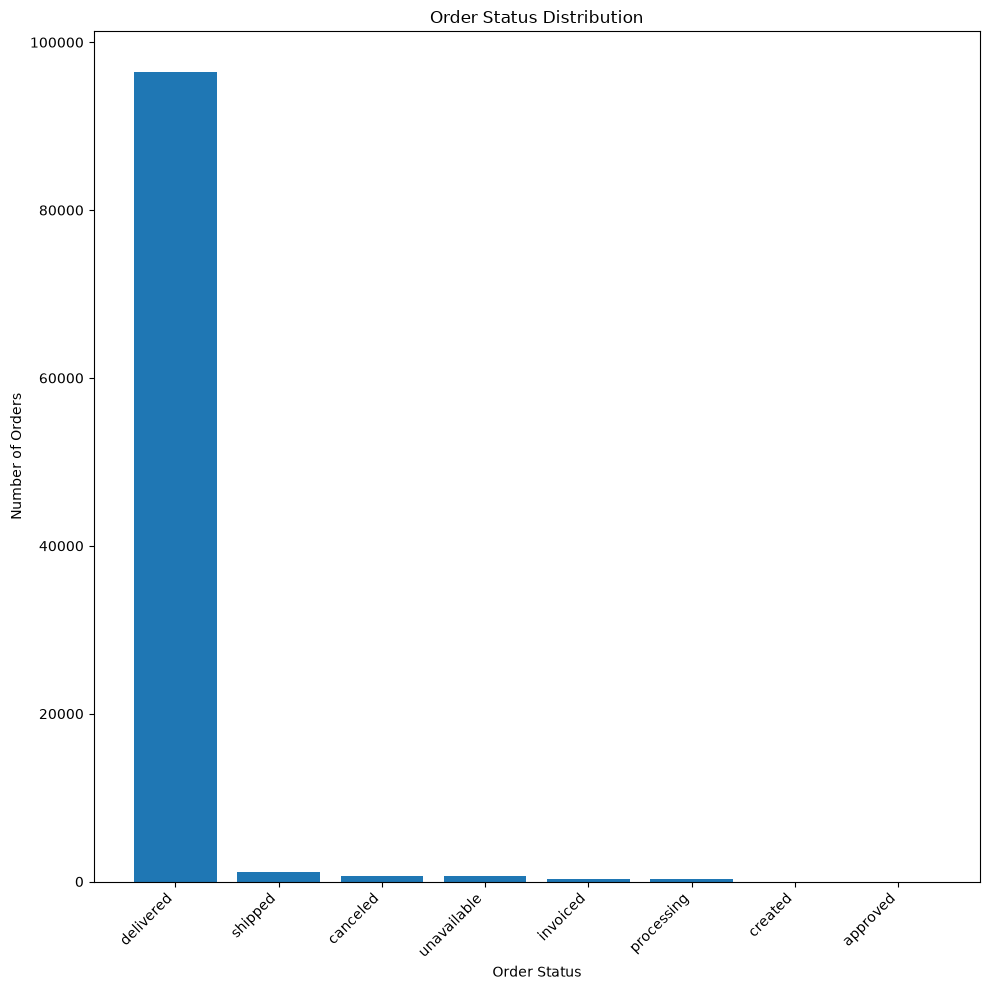

In [165]:
order_status_counts = (
    order_features["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

display(order_status_counts)

plt.figure(figsize=(10, 10))
plt.bar(
    order_status_counts["order_status"],
    order_status_counts["orders"]
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.title("Order Status Distribution")
plt.tight_layout()
plt.show()

## 7. Univariate Analysis: Payment Type

,payment_type,payments
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,unknown,3


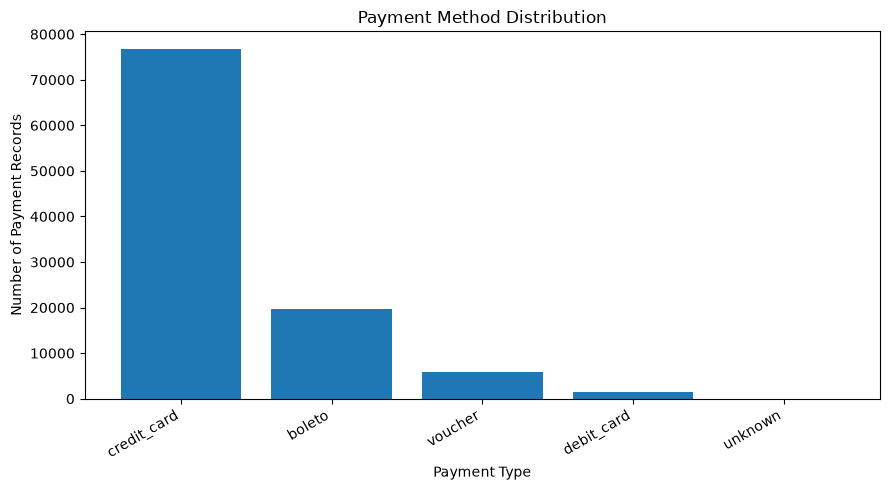

In [166]:
payment_counts = (
    order_payments["payment_type"]
    .value_counts()
    .rename_axis("payment_type")
    .reset_index(name="payments")
)

display(payment_counts)

plt.figure(figsize=(9, 5))
plt.bar(
    payment_counts["payment_type"],
    payment_counts["payments"]
)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payment Records")
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()

## 8. Univariate Analysis: Review Scores

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

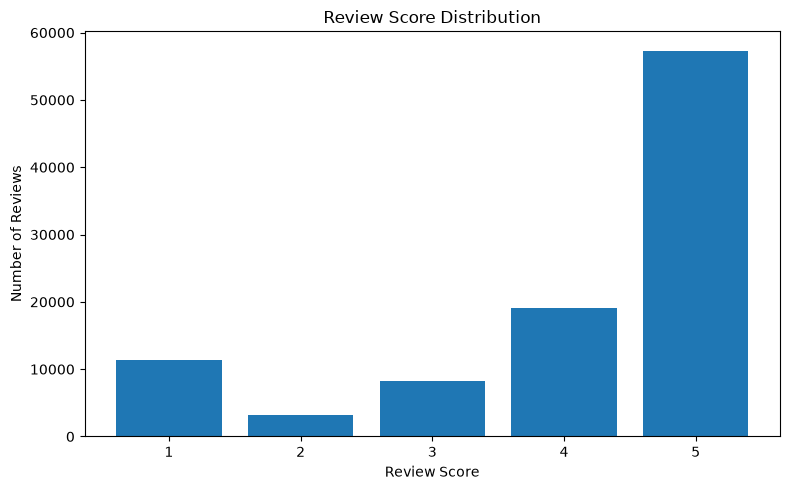

In [167]:
review_counts = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
)

display(review_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    review_counts.index.astype(str),
    review_counts.values
)
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution")
plt.tight_layout()
plt.show()

## 9. Univariate Analysis: Delivery Status

delivery_status
on_time          88650
delayed           7820
not_available     2971
Name: count, dtype: int64

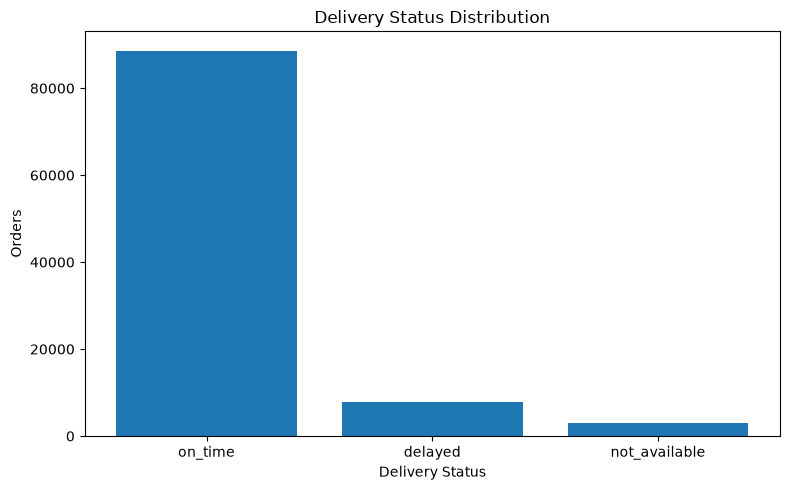

In [168]:
delivery_counts = (
    order_features["delivery_status"]
    .value_counts()
    .reindex(["on_time", "delayed", "not_available"])
    .fillna(0)
)

display(delivery_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    delivery_counts.index,
    delivery_counts.values
)
plt.xlabel("Delivery Status")
plt.ylabel("Orders")
plt.title("Delivery Status Distribution")
plt.tight_layout()
plt.show()

## 10. Univariate Analysis: Core Numerical Features

In [169]:
numerical_features = [
    "total_order_value",
    "item_revenue",
    "freight_value",
    "order_item_count",
    "delivery_days",
    "delivery_delay_days",
    "total_items_per_order",
    "freight_percentage",
    "customer_order_count",
    "customer_total_spending",
    "customer_average_order_value"
]

numerical_summary = (
    order_features[
        numerical_features
    ]
    .describe()
    .T
)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
total_order_value,99441.0,159.326166,220.058804,0.00,61.05,104.56,176.00,13664.08
item_revenue,99441.0,136.680481,210.172081,0.00,45.00,85.00,149.90,13440.00
freight_value,99441.0,22.645685,21.659564,0.00,13.72,17.09,23.92,1794.96
order_item_count,99441.0,1.132833,0.545666,0.00,1.00,1.00,1.00,21.00
delivery_days,96470.0,12.558201,9.546155,0.53,6.77,10.22,15.72,209.63
delivery_delay_days,96470.0,-11.178122,10.184356,-146.02,-16.24,-11.95,-6.39,188.98
total_items_per_order,99441.0,1.132833,0.545666,0.00,1.00,1.00,1.00,21.00
freight_percentage,98666.0,20.880393,12.574904,0.00,11.65,18.33,27.55,95.55
customer_order_count,99441.0,1.079223,0.396154,1.00,1.00,1.00,1.00,17.00
customer_total_spending,99441.0,170.650658,235.775976,0.00,63.37,110.20,188.65,13664.08


## 11. Distribution Analysis: Order Value

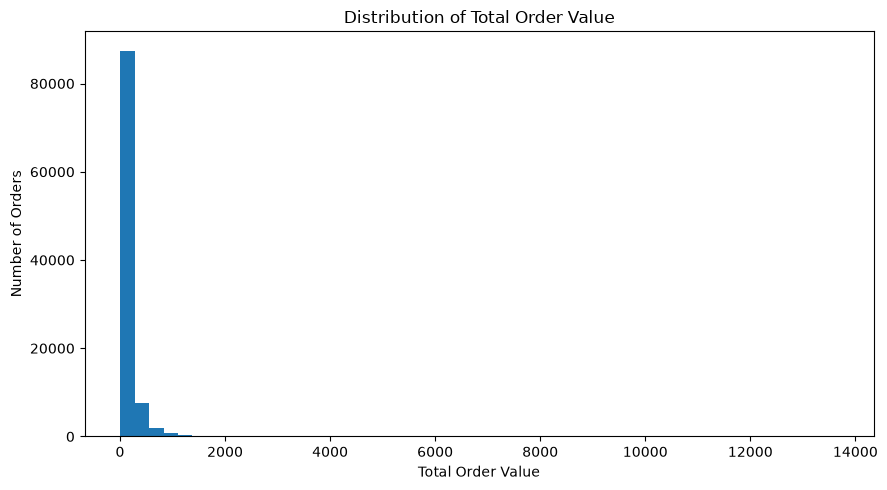

C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\680762048.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(order_value_data, vert=False)


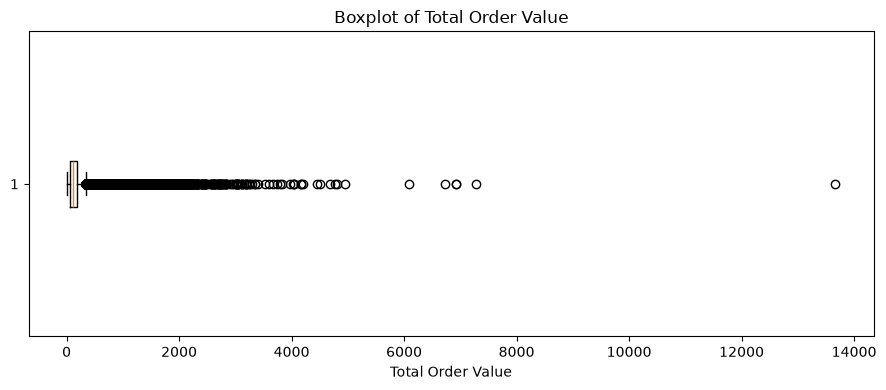

In [170]:
order_value_data = order_features.loc[
    order_features["total_order_value"] > 0,
    "total_order_value"
]

plt.figure(figsize=(9, 5))
plt.hist(order_value_data, bins=50)
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")
plt.title("Distribution of Total Order Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.boxplot(order_value_data, vert=False)
plt.xlabel("Total Order Value")
plt.title("Boxplot of Total Order Value")
plt.tight_layout()
plt.show()

## 12. Distribution Analysis: Delivery Days

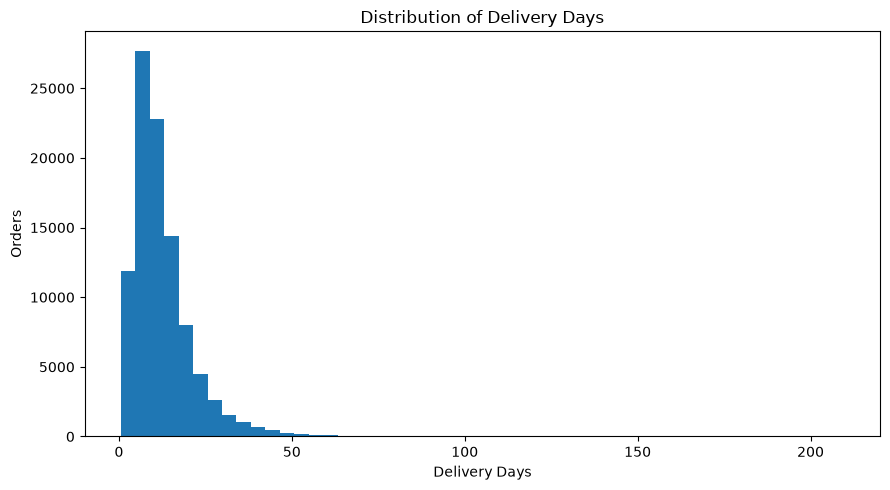

C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\2435178510.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(delivery_days_data, vert=False)


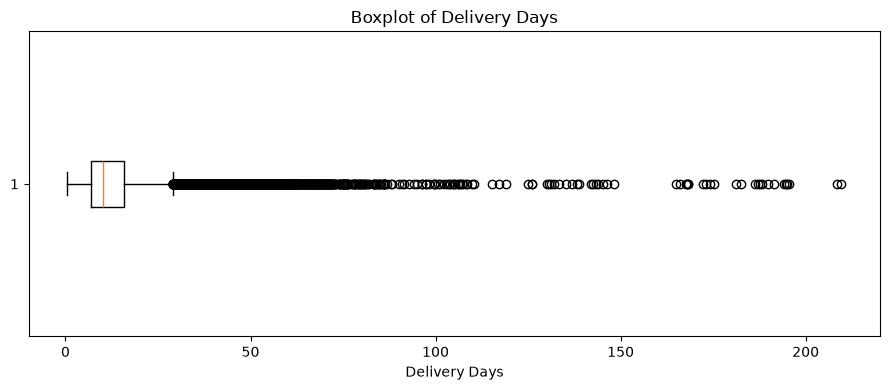

In [171]:
delivery_days_data = order_features[
    "delivery_days"
].dropna()

plt.figure(figsize=(9, 5))
plt.hist(delivery_days_data, bins=50)
plt.xlabel("Delivery Days")
plt.ylabel("Orders")
plt.title("Distribution of Delivery Days")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.boxplot(delivery_days_data, vert=False)
plt.xlabel("Delivery Days")
plt.title("Boxplot of Delivery Days")
plt.tight_layout()
plt.show()

## 13. Distribution Analysis: Customer Spending

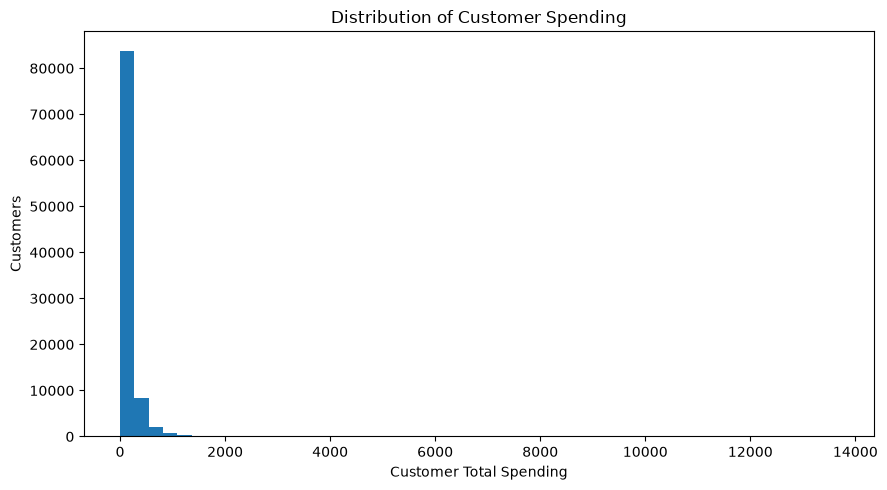

C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\3535541057.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(spending_data, vert=False)


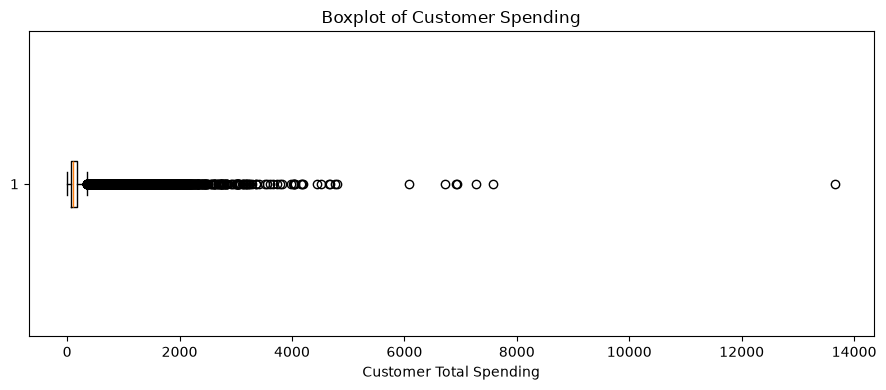

In [172]:
spending_data = customer_features[
    "customer_total_spending"
].dropna()

plt.figure(figsize=(9, 5))
plt.hist(spending_data, bins=50)
plt.xlabel("Customer Total Spending")
plt.ylabel("Customers")
plt.title("Distribution of Customer Spending")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.boxplot(spending_data, vert=False)
plt.xlabel("Customer Total Spending")
plt.title("Boxplot of Customer Spending")
plt.tight_layout()
plt.show()

## 14. Trend Analysis: Monthly Orders and Order Value

,purchase_period,orders,total_order_value,product_revenue,average_order_value
0,2016-09,4,354.75,267.36,88.687500
1,2016-10,324,56808.84,49507.66,175.335926
2,2016-12,1,19.62,10.90,19.620000
3,2017-01,800,137188.49,120312.87,171.485613
4,2017-02,1780,286280.62,247303.02,160.831809
5,2017-03,2682,432048.59,374344.30,161.091943
6,2017-04,2404,412422.24,359927.23,171.556672
7,2017-05,3700,586190.95,506071.14,158.429986
8,2017-06,3245,502963.04,433038.60,154.996314
9,2017-07,4026,584971.62,498031.48,145.298465


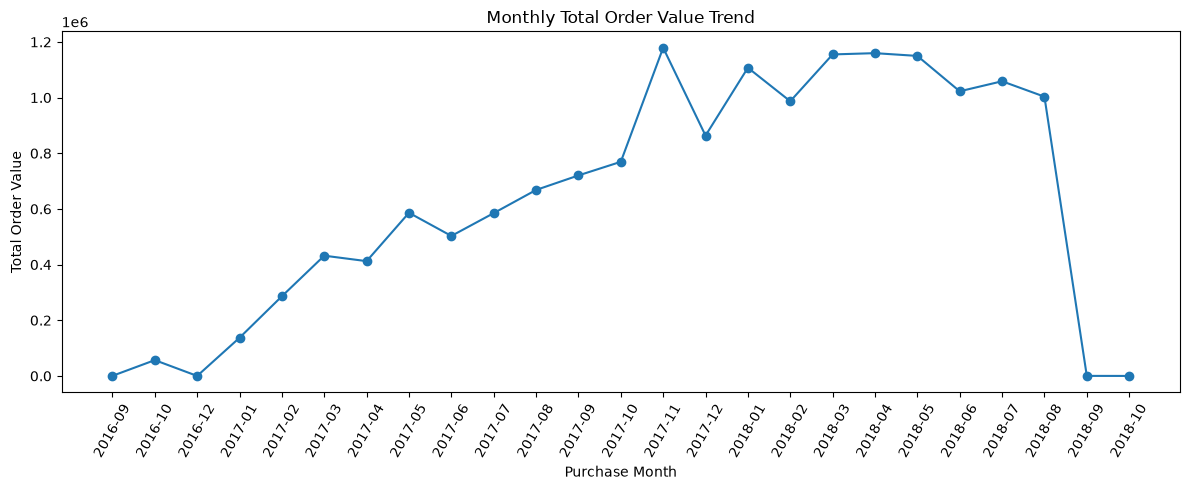

In [173]:
monthly_trend = (
    order_features
    .groupby(
        "purchase_period",
        as_index=False
    )
    .agg(
        orders=(
            "order_id",
            "nunique"
        ),
        total_order_value=(
            "total_order_value",
            "sum"
        ),
        product_revenue=(
            "item_revenue",
            "sum"
        ),
        average_order_value=(
            "total_order_value",
            "mean"
        )
    )
    .sort_values(
        "purchase_period"
    )
)

display(monthly_trend)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend["purchase_period"],
    monthly_trend["total_order_value"],
    marker="o"
)

plt.xlabel("Purchase Month")
plt.ylabel("Total Order Value")
plt.title("Monthly Total Order Value Trend")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

## 15. Trend Analysis: Monthly Order Volume

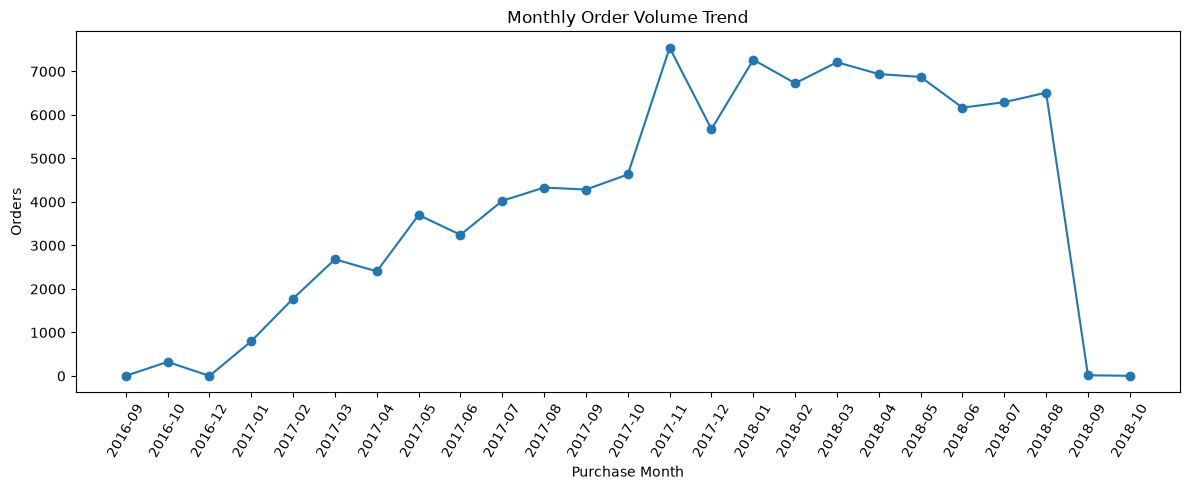

In [174]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_trend["purchase_period"],
    monthly_trend["orders"],
    marker="o"
)
plt.xlabel("Purchase Month")
plt.ylabel("Orders")
plt.title("Monthly Order Volume Trend")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 16. Time Pattern Analysis: Day of Week

purchase_day_of_week
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

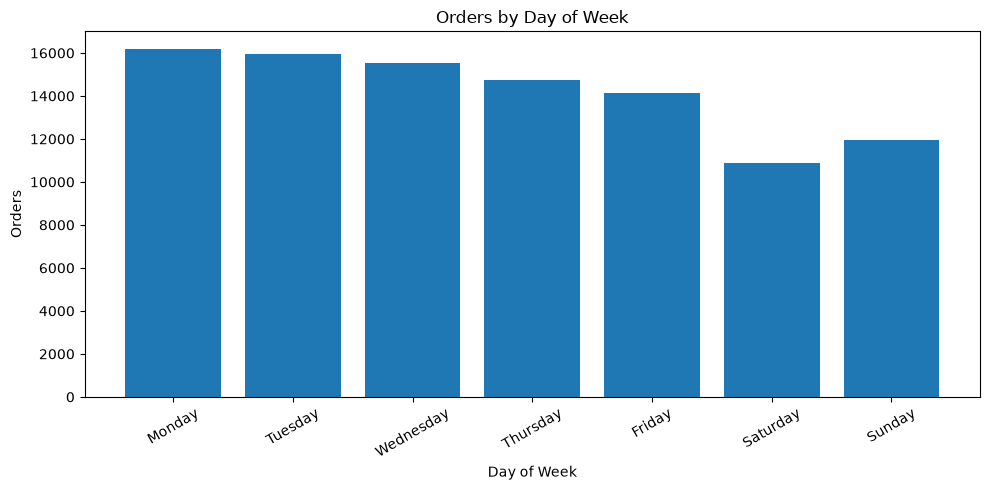

In [175]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = (
    order_features["purchase_day_of_week"]
    .value_counts()
    .reindex(day_order)
)

display(day_counts)

plt.figure(figsize=(10, 5))
plt.bar(
    day_counts.index,
    day_counts.values
)
plt.xlabel("Day of Week")
plt.ylabel("Orders")
plt.title("Orders by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 17. Time Pattern Analysis: Purchase Hour

purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64

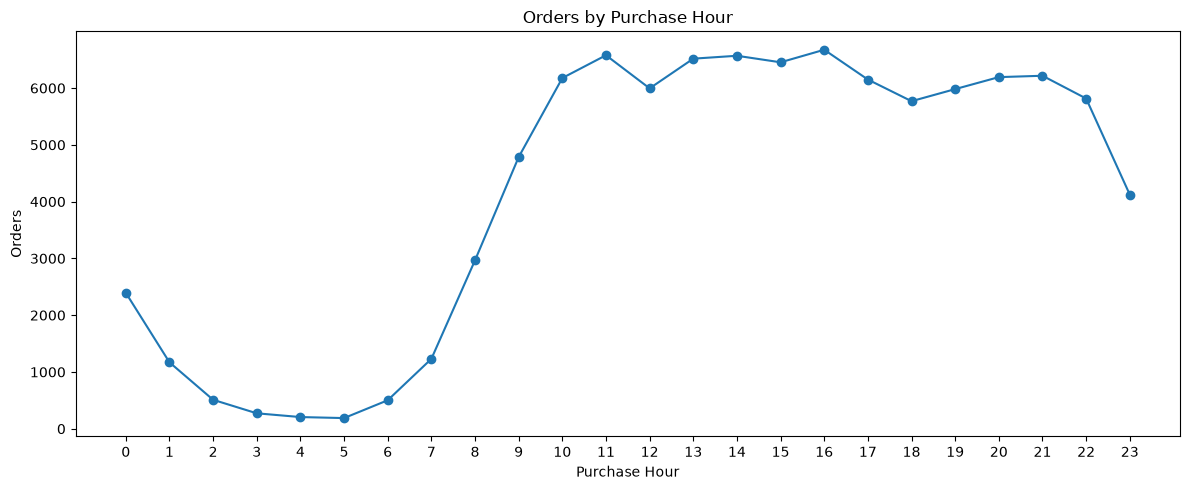

In [176]:
hour_counts = (
    order_features["purchase_hour"]
    .value_counts()
    .sort_index()
)

display(hour_counts)

plt.figure(figsize=(12, 5))
plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o"
)
plt.xlabel("Purchase Hour")
plt.ylabel("Orders")
plt.title("Orders by Purchase Hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 18. Bivariate Analysis: Category Performance

,category_name,category_order_count,category_item_count,category_revenue,category_average_price
11,health_beauty,9022,9670,1258681.34,146.776607
66,watches_gifts,5799,5991,1205005.68,335.905481
13,bed_bath_table,10160,11115,1036988.68,107.463381
32,sports_leisure,7858,8641,988048.97,135.441691
44,computers_accessories,6887,7827,911954.32,156.028732
54,furniture_decor,6781,8334,729762.49,103.233978
26,cool_stuff,3658,3796,635290.85,214.696681
73,housewares,6019,6964,632248.66,98.561100
8,auto,3991,4235,592720.11,152.576804
40,garden_tools,3607,4347,485256.46,222.614460


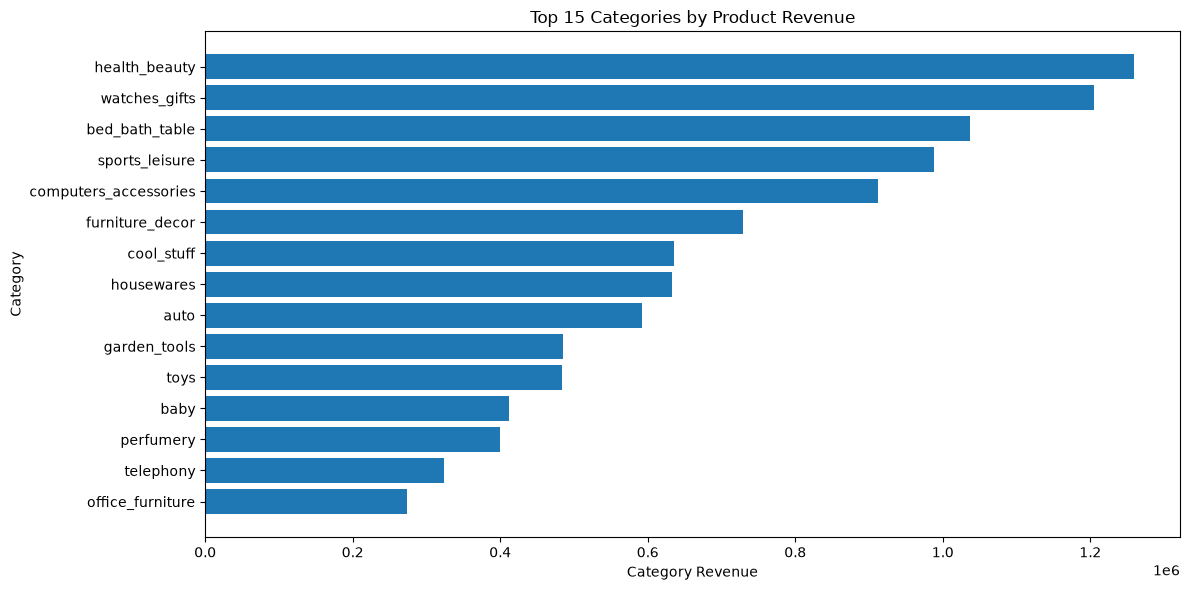

In [177]:
category_performance = (
    category_features
    .sort_values(
        "category_revenue",
        ascending=False
    )
)

display(
    category_performance[
        [
            "category_name",
            "category_order_count",
            "category_item_count",
            "category_revenue",
            "category_average_price"
        ]
    ].head(20)
)

top_categories = category_performance.head(15)

plt.figure(figsize=(12, 6))
plt.barh(
    top_categories["category_name"].iloc[::-1],
    top_categories["category_revenue"].iloc[::-1]
)
plt.xlabel("Category Revenue")
plt.ylabel("Category")
plt.title("Top 15 Categories by Product Revenue")
plt.tight_layout()
plt.show()

## 19. Bivariate Analysis: Top Products

,product_id,category_name,product_order_count,product_item_count,product_revenue,product_average_price
24086,bb50f2e236e5eea0100680137654686c,health_beauty,187,195,63885.00,327.615385
14068,6cdd53843498f92890544667809f1595,health_beauty,151,156,54730.20,350.834615
27613,d6160fb7873f184099d9bc95e30376af,computers,35,35,48899.34,1397.124000
27039,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,323,343,47214.51,137.651633
19742,99a4788cb24856965c36a24e339b6058,bed_bath_table,467,488,43025.56,88.167131
8051,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,255,274,41082.60,149.936496
4996,25c38557cf793876c5abdd5931f922db,baby,38,38,38907.32,1023.876842
12351,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,63,37733.90,598.950794
10867,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,306,323,37683.42,116.666935
22112,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,431,527,37608.90,71.364137


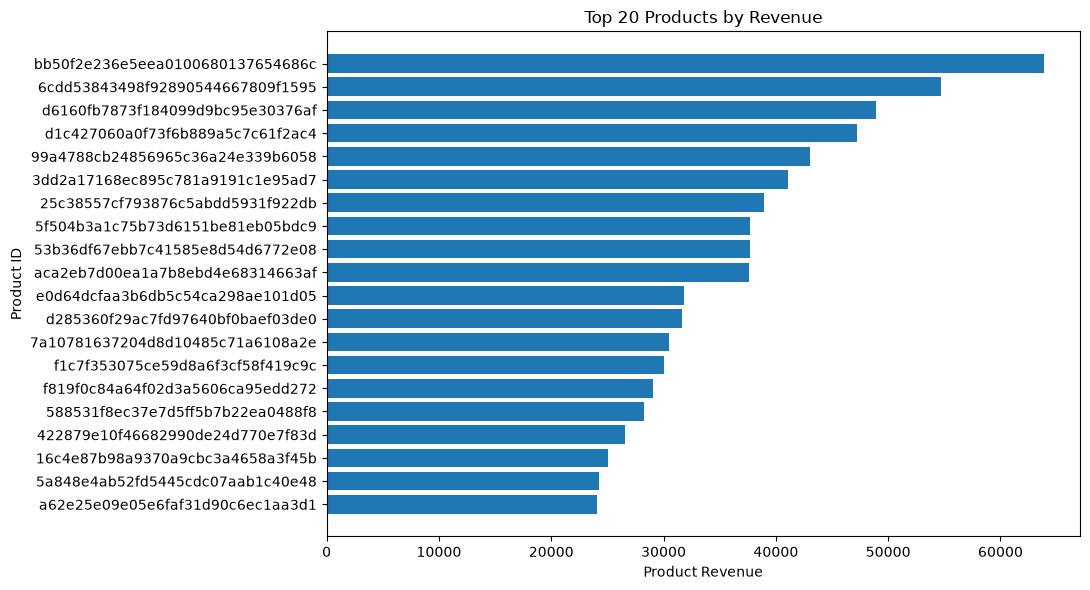

In [178]:
top_products = (
    product_features
    .sort_values(
        "product_revenue",
        ascending=False
    )
    .head(20)
)

display(
    top_products[
        [
            "product_id",
            "category_name",
            "product_order_count",
            "product_item_count",
            "product_revenue",
            "product_average_price"
        ]
    ]
)

plt.figure(figsize=(11, 6))
plt.barh(
    top_products["product_id"].iloc[::-1],
    top_products["product_revenue"].iloc[::-1]
)
plt.xlabel("Product Revenue")
plt.ylabel("Product ID")
plt.title("Top 20 Products by Revenue")
plt.tight_layout()
plt.show()

## 20. Bivariate Analysis: Seller Performance

,seller_id,seller_revenue,seller_order_count,seller_item_count,seller_unique_products
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,95
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,23
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,399
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,289
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,198
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,186
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,222
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,149
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,154
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,104


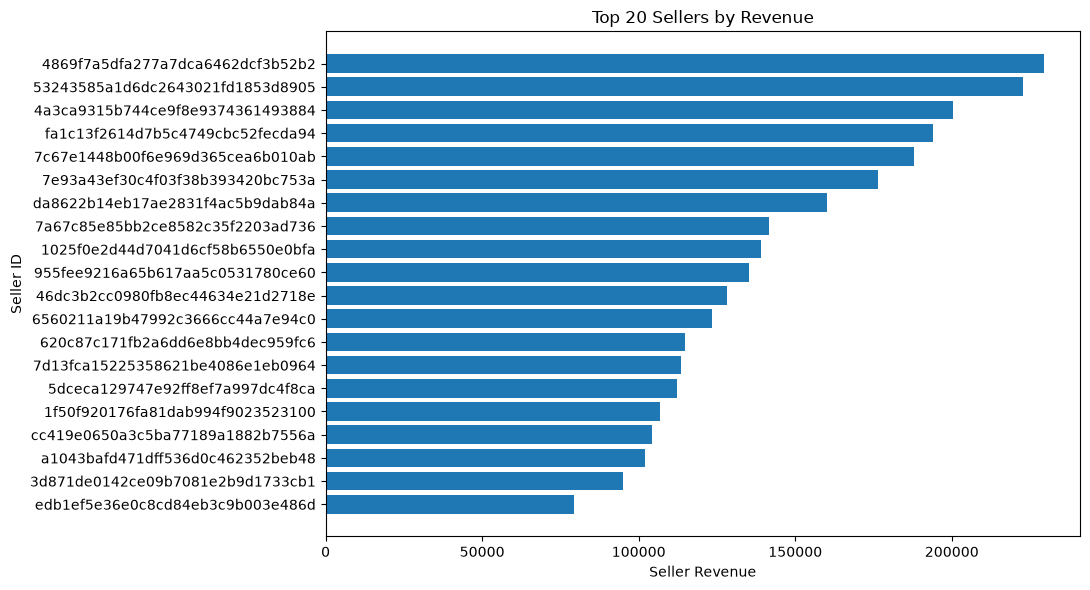

In [179]:
top_sellers = (
    seller_features
    .sort_values(
        "seller_revenue",
        ascending=False
    )
    .head(20)
)

display(
    top_sellers[
        [
            "seller_id",
            "seller_revenue",
            "seller_order_count",
            "seller_item_count",
            "seller_unique_products"
        ]
    ]
)

plt.figure(figsize=(11, 6))
plt.barh(
    top_sellers["seller_id"].iloc[::-1],
    top_sellers["seller_revenue"].iloc[::-1]
)
plt.xlabel("Seller Revenue")
plt.ylabel("Seller ID")
plt.title("Top 20 Sellers by Revenue")
plt.tight_layout()
plt.show()

## 21. Bivariate Analysis: Customer Spending vs Order Frequency

,customer_order_count,customer_total_spending
customer_order_count,1.000000,0.122369
customer_total_spending,0.122369,1.000000


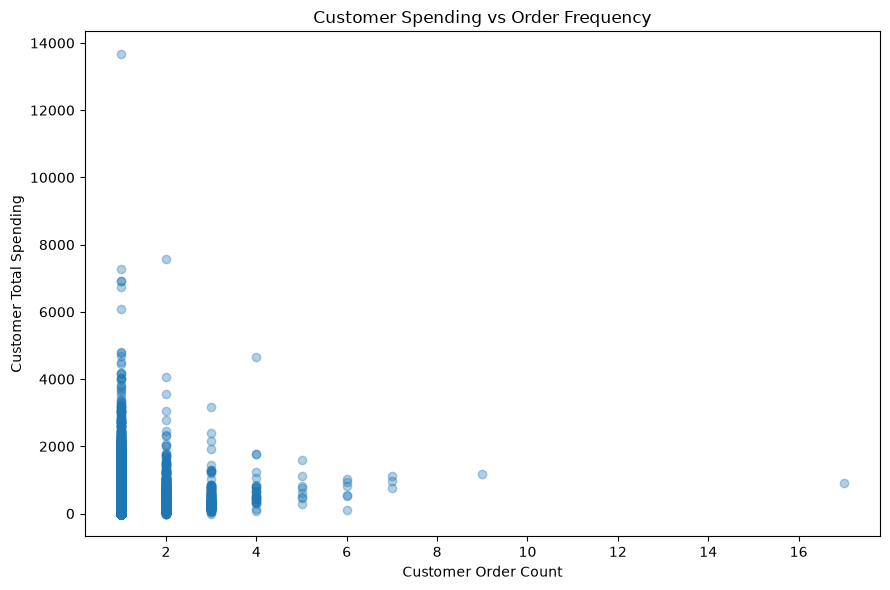

In [180]:
customer_spend_frequency = (
    customer_features[
        [
            "customer_order_count",
            "customer_total_spending"
        ]
    ]
    .corr()
)

display(
    customer_spend_frequency
)

plt.figure(figsize=(9, 6))

plt.scatter(
    customer_features[
        "customer_order_count"
    ],
    customer_features[
        "customer_total_spending"
    ],
    alpha=0.35
)

plt.xlabel("Customer Order Count")
plt.ylabel("Customer Total Spending")
plt.title(
    "Customer Spending vs Order Frequency"
)

plt.tight_layout()
plt.show()

## 22. Bivariate Analysis: Order Value vs Review Score

,review_score,average_order_value,median_order_value,orders
0,1.000000,185.464685,114.440,11316
1,1.500000,204.702500,175.075,8
2,2.000000,168.451158,110.140,3125
3,2.500000,129.309118,106.075,34
4,3.000000,150.217166,102.355,8136
5,3.333333,42.110000,42.110,1
6,3.500000,143.645600,121.900,25
7,4.000000,154.596125,102.660,19018
8,4.333333,42.770000,42.770,1
9,4.500000,121.889815,84.675,54


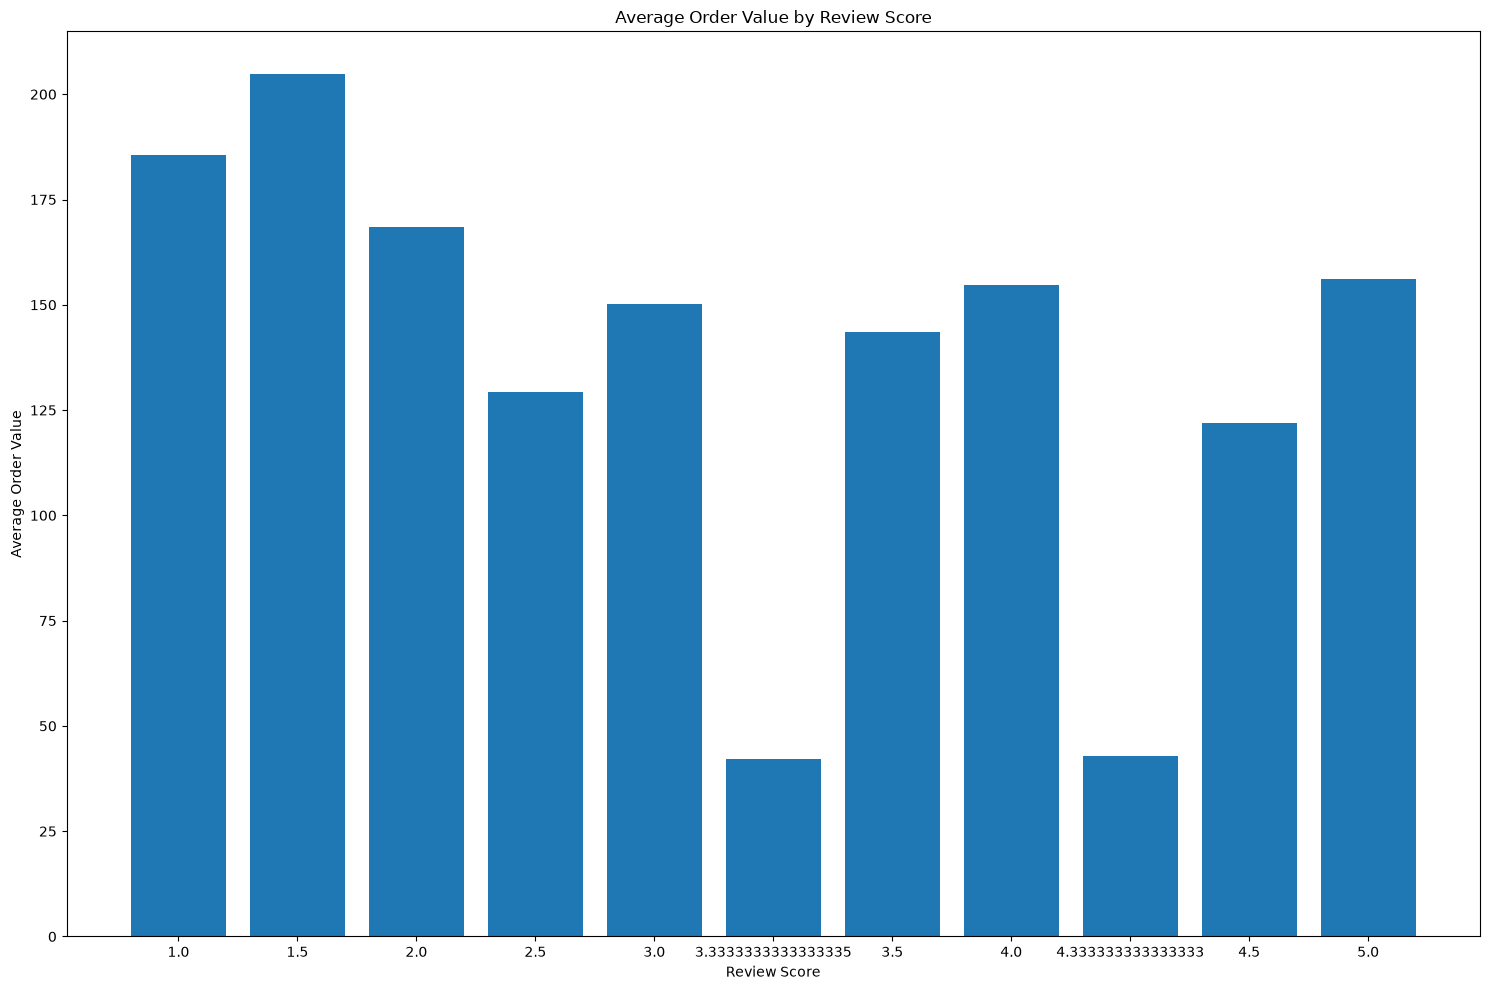

In [181]:
review_order_value = (
    order_features
    .dropna(
        subset=[
            "review_score",
            "total_order_value"
        ]
    )
    .groupby(
        "review_score",
        as_index=False
    )
    .agg(
        average_order_value=(
            "total_order_value",
            "mean"
        ),
        median_order_value=(
            "total_order_value",
            "median"
        ),
        orders=(
            "order_id",
            "nunique"
        )
    )
)

display(
    review_order_value
)

plt.figure(figsize=(15, 10))

plt.bar(
    review_order_value[
        "review_score"
    ].astype(str),
    review_order_value[
        "average_order_value"
    ]
)

plt.xlabel("Review Score")
plt.ylabel("Average Order Value")
plt.title(
    "Average Order Value by Review Score"
)

plt.tight_layout()
plt.show()

## 23. Bivariate Analysis: Delivery Status vs Review Score

,delivery_status,average_review_score,median_review_score,orders
0,delayed,2.565121,2.0,7655
1,on_time,4.294295,5.0,88169


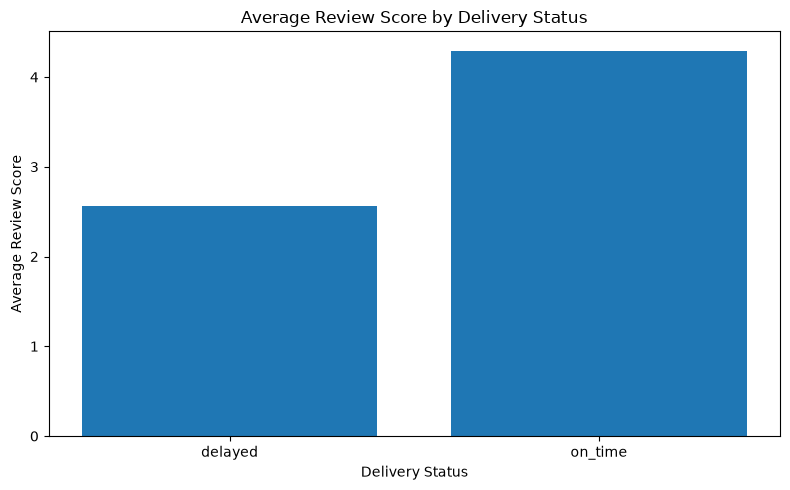

In [182]:
delivery_review = (
    order_features
    .dropna(
        subset=[
            "review_score"
        ]
    )
    .query(
        "delivery_status in ['on_time', 'delayed']"
    )
    .groupby(
        "delivery_status",
        as_index=False
    )
    .agg(
        average_review_score=(
            "review_score",
            "mean"
        ),
        median_review_score=(
            "review_score",
            "median"
        ),
        orders=(
            "order_id",
            "nunique"
        )
    )
)

display(
    delivery_review
)

plt.figure(figsize=(8, 5))

plt.bar(
    delivery_review[
        "delivery_status"
    ],
    delivery_review[
        "average_review_score"
    ]
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title(
    "Average Review Score by Delivery Status"
)

plt.tight_layout()
plt.show()

## 24. Bivariate Analysis: Delivery Delay vs Review Score

,review_score,average_delivery_delay,median_delivery_delay,orders
0,1.0,12.671342,8.870,3533
1,1.5,25.610000,25.610,1
2,2.0,10.008455,7.630,602
3,2.5,17.098333,14.340,6
4,3.0,7.865721,3.870,867
5,3.5,2.123333,0.700,3
6,4.0,6.465398,1.890,943
7,4.5,0.755000,0.755,2
8,5.0,5.017438,1.790,1698


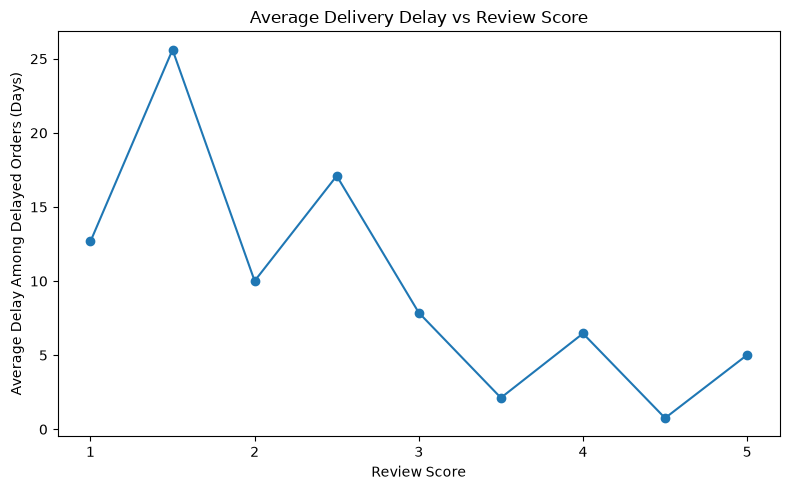

In [200]:
delay_review = (
    order_features[
        [
            "order_id",
            "delivery_status",
            "delivery_delay_days",
            "review_score"
        ]
    ]
    .query(
        "delivery_status == 'delayed'"
    )
    .dropna(
        subset=[
            "delivery_delay_days",
            "review_score"
        ]
    )
    .groupby(
        "review_score",
        as_index=False
    )
    .agg(
        average_delivery_delay=(
            "delivery_delay_days",
            "mean"
        ),
        median_delivery_delay=(
            "delivery_delay_days",
            "median"
        ),
        orders=(
            "order_id",
            "nunique"
        )
    )
)

display(
    delay_review
)

plt.figure(figsize=(8, 5))

plt.plot(
    delay_review["review_score"],
    delay_review["average_delivery_delay"],
    marker="o"
)

plt.xlabel(
    "Review Score"
)

plt.ylabel(
    "Average Delay Among Delayed Orders (Days)"
)

plt.title(
    "Average Delivery Delay vs Review Score"
)

plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.tight_layout()
plt.show()

## 25. Bivariate Analysis: Payment Type vs Order Status

,payment_type,orders
0,credit_card,74935
1,boleto,19784
2,voucher,3191
3,debit_card,1527
4,unknown,3


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0,95,2,19191,67,70,209,150
credit_card,2,432,3,72785,231,219,836,427
debit_card,0,7,0,1484,6,2,22,6
unknown,0,3,0,0,0,0,0,0
voucher,0,88,0,3017,10,10,40,26


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0.0,0.48,0.01,97.00,0.34,0.35,1.06,0.76
credit_card,0.0,0.58,0.00,97.13,0.31,0.29,1.12,0.57
debit_card,0.0,0.46,0.00,97.18,0.39,0.13,1.44,0.39
unknown,0.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00
voucher,0.0,2.76,0.00,94.55,0.31,0.31,1.25,0.81


<Figure size 1100x600 with 0 Axes>

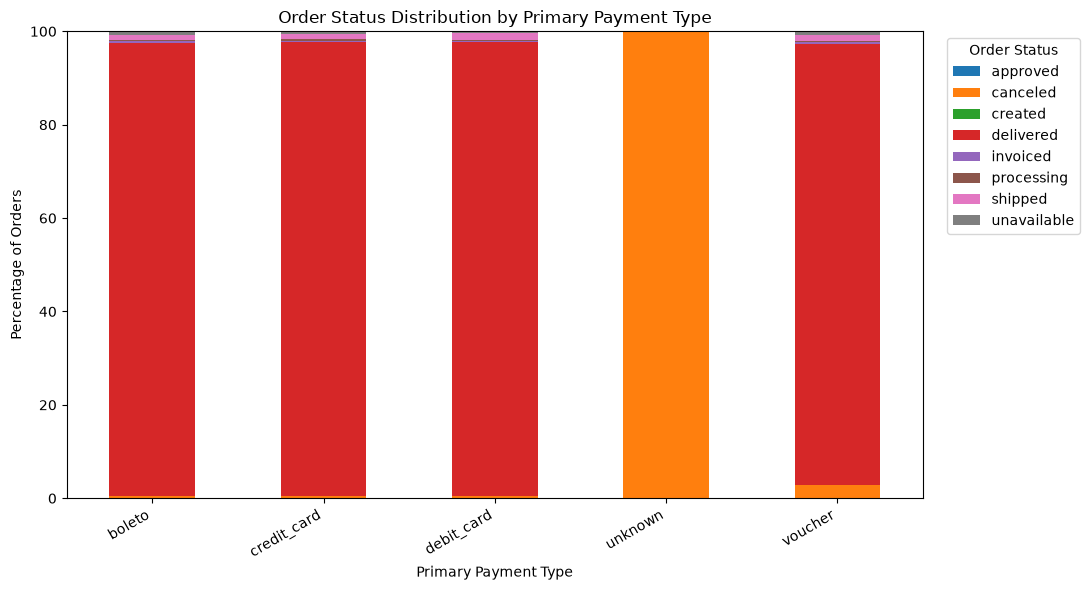

In [201]:
payment_counts = (
    payment_order[
        "payment_type"
    ]
    .value_counts()
    .rename_axis("payment_type")
    .reset_index(
        name="orders"
    )
)

display(
    payment_counts
)

payment_status_table = pd.crosstab(
    payment_order["payment_type"],
    payment_order["order_status"]
)

display(
    payment_status_table
)

payment_status_percentage = (
    payment_status_table
    .div(
        payment_status_table.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    payment_status_percentage.round(2)
)

plt.figure(figsize=(11, 6))

payment_status_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.xlabel(
    "Primary Payment Type"
)

plt.ylabel(
    "Percentage of Orders"
)

plt.title(
    "Order Status Distribution by Primary Payment Type"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 26. Multivariate Analysis: Numeric Correlation Matrix

,total_order_value,item_revenue,freight_value,order_item_count,delivery_days,delivery_delay_days,purchase_hour,customer_order_count,customer_total_spending,customer_average_order_value,review_score
total_order_value,1.000,0.996,0.495,0.197,0.070,-0.018,0.005,-0.015,0.950,0.993,-0.036
item_revenue,0.996,1.000,0.416,0.161,0.056,-0.014,0.005,-0.015,0.946,0.989,-0.030
freight_value,0.495,0.416,1.000,0.445,0.167,-0.050,0.001,-0.002,0.476,0.490,-0.073
order_item_count,0.197,0.161,0.445,1.000,-0.019,-0.032,-0.008,0.025,0.201,0.192,-0.083
delivery_days,0.070,0.056,0.167,-0.019,1.000,0.607,0.002,-0.011,0.066,0.070,-0.334
delivery_delay_days,-0.018,-0.014,-0.050,-0.032,0.607,1.000,0.023,-0.016,-0.021,-0.017,-0.267
purchase_hour,0.005,0.005,0.001,-0.008,0.002,0.023,1.000,-0.009,0.001,0.005,0.006
customer_order_count,-0.015,-0.015,-0.002,0.025,-0.011,-0.016,-0.009,1.000,0.188,-0.015,0.013
customer_total_spending,0.950,0.946,0.476,0.201,0.066,-0.021,0.001,0.188,1.000,0.956,-0.033
customer_average_order_value,0.993,0.989,0.490,0.192,0.070,-0.017,0.005,-0.015,0.956,1.000,-0.036


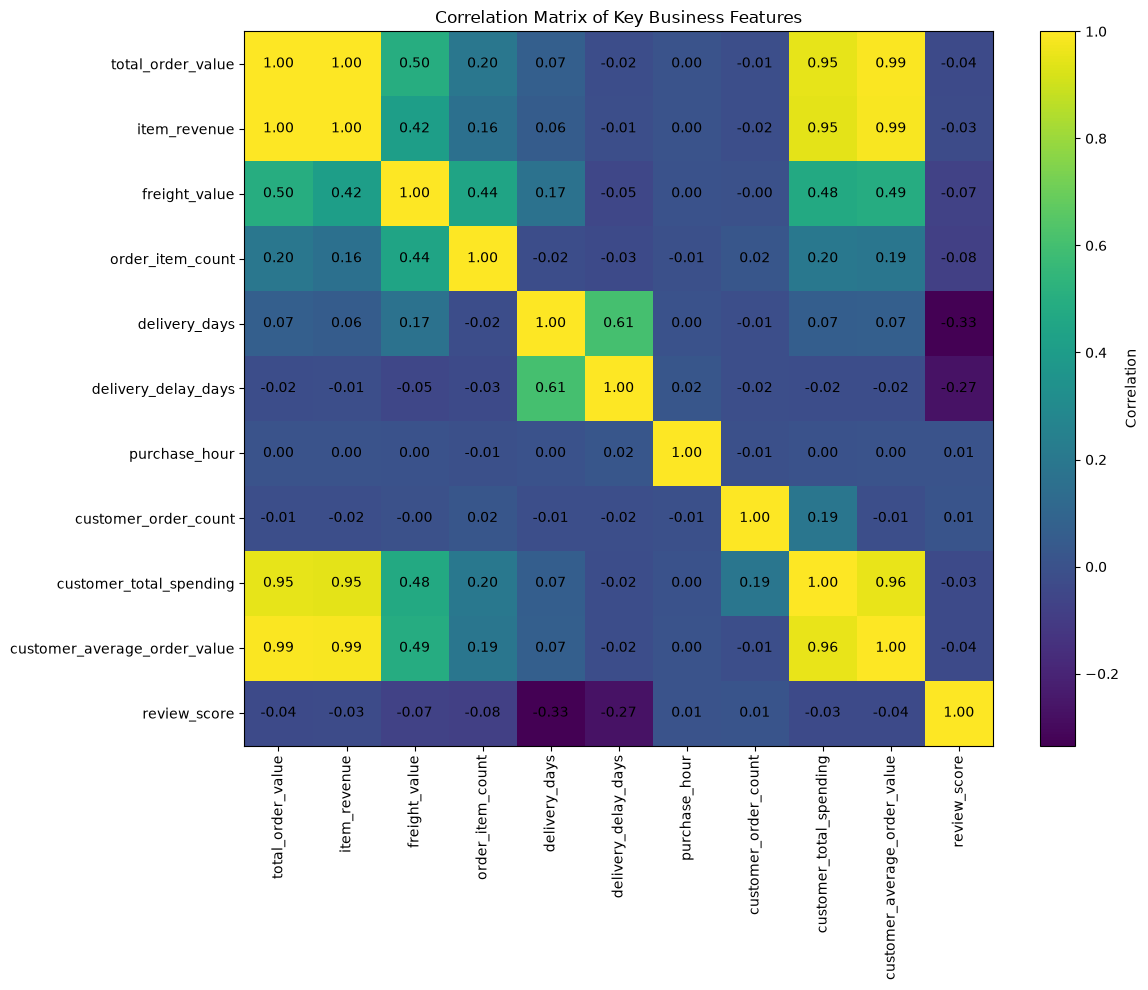

In [185]:
correlation_columns = [
    "total_order_value",
    "item_revenue",
    "freight_value",
    "order_item_count",
    "delivery_days",
    "delivery_delay_days",
    "purchase_hour",
    "customer_order_count",
    "customer_total_spending",
    "customer_average_order_value",
    "review_score"
]

correlation_data = (
    order_features[
        correlation_columns
    ]
    .corr()
)

display(
    correlation_data.round(3)
)

plt.figure(figsize=(12, 10))

plt.imshow(
    correlation_data,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_data.columns)),
    correlation_data.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_data.index)),
    correlation_data.index
)

for row in range(
    len(correlation_data.index)
):
    for column in range(
        len(correlation_data.columns)
    ):
        plt.text(
            column,
            row,
            f"{correlation_data.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Correlation Matrix of Key Business Features"
)

plt.tight_layout()
plt.show()

## 27. Multivariate Analysis: Category and Review Score

,category_name,average_review_score,reviews
7,bed_bath_table,3.970740,9313
43,health_beauty,4.181203,8771
65,sports_leisure,4.167362,7669
15,computers_accessories,4.026245,6649
39,furniture_decor,4.009691,6398
49,housewares,4.142221,5843
71,watches_gifts,4.065459,5576
68,telephony,4.003119,4168
5,auto,4.090147,3877
69,toys,4.189333,3853


C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\1184031420.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\1184031420.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


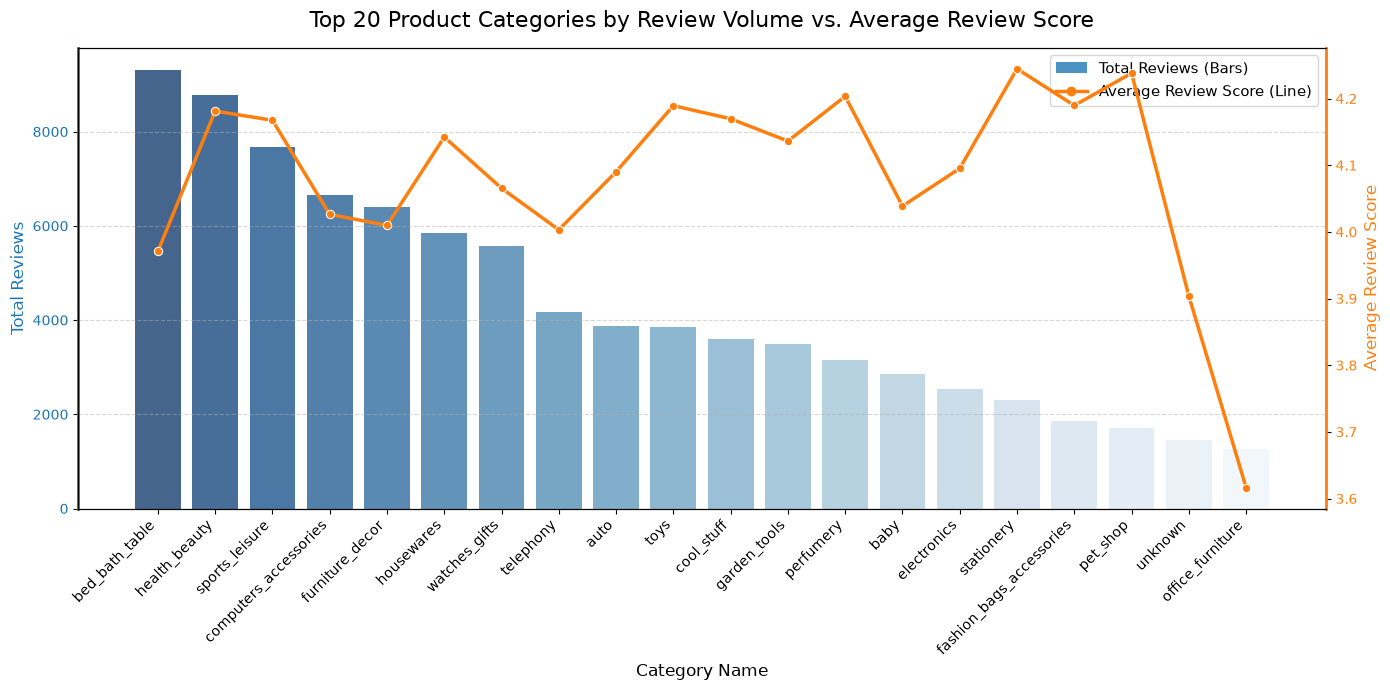

In [186]:
order_category_review = (
    order_category[["order_id", "category_name"]].drop_duplicates()
)

review_map = (
    order_features.drop_duplicates("order_id")
    .set_index("order_id")["review_score"]
)

order_category_review["review_score"] = order_category_review["order_id"].map(
    review_map
)

category_review = (
    order_category_review.dropna(subset=["review_score", "category_name"])
    .groupby("category_name", as_index=False)
    .agg(
        average_review_score=("review_score", "mean"),
        reviews=("review_score", "count"),
    )
    .sort_values("reviews", ascending=False)
)

display(category_review.head(20))

fig, ax1 = plt.subplots(figsize=(14, 7))

bar_plot = sns.barplot(
    data=category_review.head(20),
    x="category_name",
    y="reviews",
    ax=ax1,
    palette="Blues_r",
    alpha=0.8,
)

ax1.set_title(
    "Top 20 Product Categories by Review Volume vs. Average Review Score",
    fontsize=16,
    pad=15,
)
ax1.set_xlabel("Category Name", fontsize=12)
ax1.set_ylabel("Total Reviews", color="tab:blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.spines["left"].set_color("tab:blue")
ax1.spines["left"].set_linewidth(2)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = ax1.twinx()

line_plot = sns.lineplot(
    data=category_review.head(20),
    x="category_name",
    y="average_review_score",
    ax=ax2,
    color="tab:orange",
    marker="o",
    linewidth=2.5,
)

ax2.set_ylabel("Average Review Score", color="tab:orange", fontsize=12)
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.spines["right"].set_color("tab:orange")
ax2.spines["right"].set_linewidth(2)

legend_handles = [
    Patch(facecolor="tab:blue", alpha=0.8, label="Total Reviews (Bars)"),
    Line2D(
        [],
        [],
        color="tab:orange",
        marker="o",
        linewidth=2.5,
        label="Average Review Score (Line)",
    ),
]

ax1.legend(handles=legend_handles, loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

## 28. Geography Analysis: Orders and Value by Customer State

,customer_state,orders,total_order_value,average_order_value
25,sp,41746,5921678.12,141.850192
18,rj,12852,2129681.98,165.708215
10,mg,11635,1856161.49,159.532573
22,rs,5466,885826.76,162.061244
17,pr,5045,800935.44,158.758264
4,ba,3380,611506.67,180.919133
23,sc,3637,610213.60,167.779379
6,df,2140,353229.44,165.060486
8,go,2020,347706.93,172.132144
7,es,2033,324801.91,159.764835


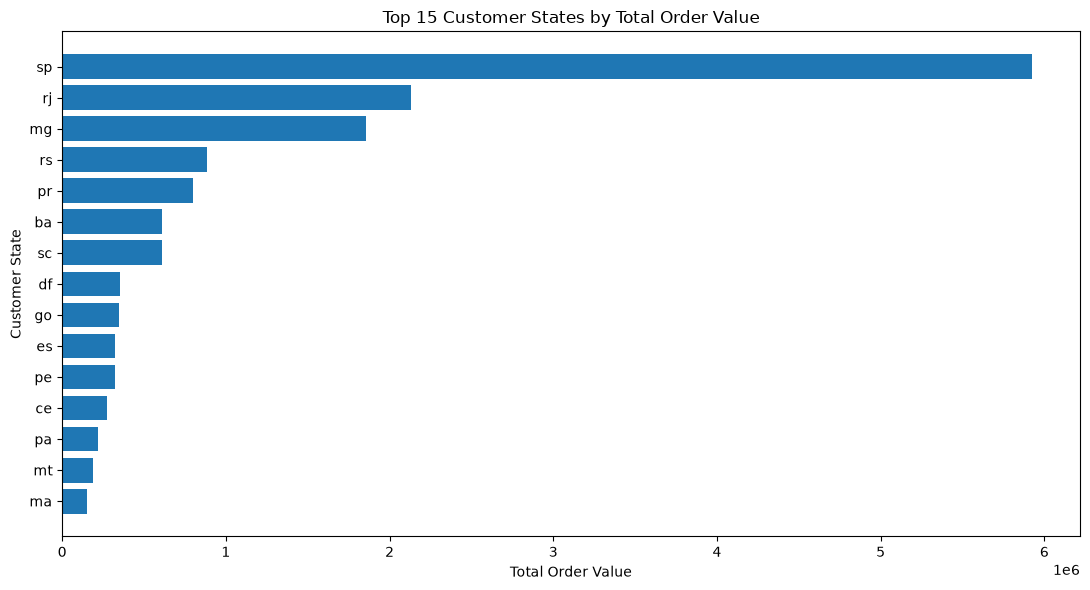

In [187]:
state_orders = (
    order_features[
        [
            "order_id",
            "customer_state",
            "total_order_value"
        ]
    ]
    .groupby(
        "customer_state",
        as_index=False
    )
    .agg(
        orders=("order_id", "nunique"),
        total_order_value=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .sort_values(
        "total_order_value",
        ascending=False
    )
)

display(state_orders.head(20))

plt.figure(figsize=(11, 6))

plt.barh(
    state_orders["customer_state"].head(15).iloc[::-1],
    state_orders["total_order_value"].head(15).iloc[::-1]
)

plt.xlabel("Total Order Value")
plt.ylabel("Customer State")
plt.title("Top 15 Customer States by Total Order Value")

plt.tight_layout()
plt.show()

## 29. Customer Segmentation by Spending

,spending_segment,customers,average_spending,average_orders,repeat_customer_rate
0,Low,24033,42.004048,1.003079,0.295427
1,Medium,24018,82.911679,1.013906,1.348988
2,High,24021,140.571238,1.032305,3.080638
3,Very High,24024,394.024123,1.089952,7.750583


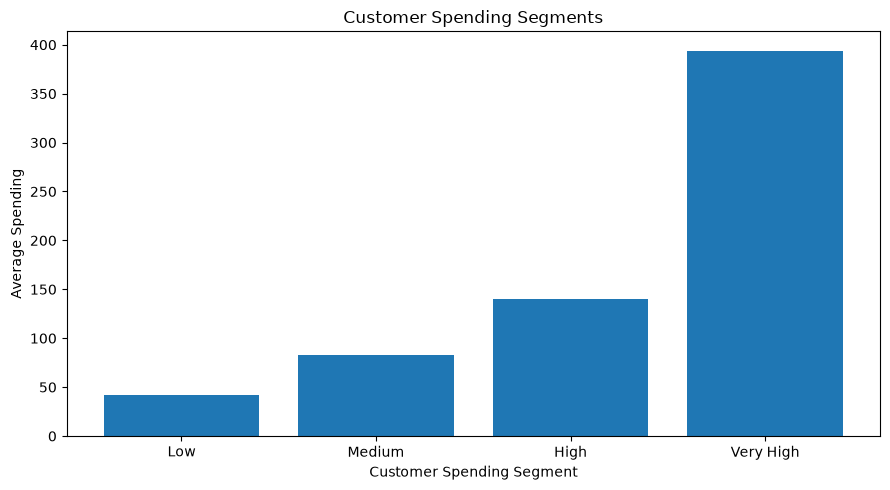

In [188]:
customer_features["spending_segment"] = pd.qcut(
    customer_features[
        "customer_total_spending"
    ],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

customer_segment_summary = (
    customer_features
    .groupby(
        "spending_segment",
        observed=True
    )
    .agg(
        customers=(
            "customer_unique_id",
            "nunique"
        ),
        average_spending=(
            "customer_total_spending",
            "mean"
        ),
        average_orders=(
            "customer_order_count",
            "mean"
        ),
        repeat_customer_rate=(
            "repeat_customer_indicator",
            "mean"
        )
    )
    .reset_index()
)

customer_segment_summary[
    "repeat_customer_rate"
] = (
    customer_segment_summary[
        "repeat_customer_rate"
    ]
    * 100
)

display(
    customer_segment_summary
)

plt.figure(figsize=(9, 5))

plt.bar(
    customer_segment_summary[
        "spending_segment"
    ].astype(str),
    customer_segment_summary[
        "average_spending"
    ]
)

plt.xlabel("Customer Spending Segment")
plt.ylabel("Average Spending")
plt.title(
    "Customer Spending Segments"
)

plt.tight_layout()
plt.show()

## 30. Customer Retention Analysis

,customer_type,customers,percentage
0,One-time,93099,96.881244
1,Repeat,2997,3.118756


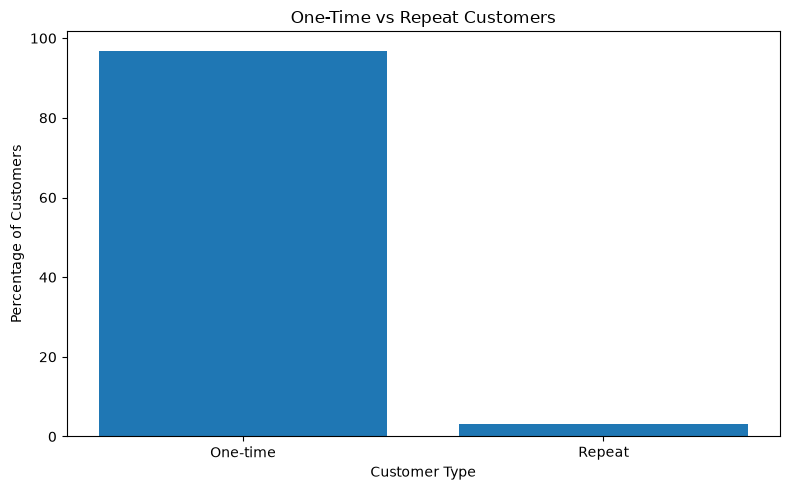

In [189]:
retention_summary = pd.DataFrame({
    "customer_type": [
        "One-time",
        "Repeat"
    ],
    "customers": [
        (
            customer_features[
                "repeat_customer_indicator"
            ].eq(0).sum()
        ),
        (
            customer_features[
                "repeat_customer_indicator"
            ].eq(1).sum()
        )
    ]
})

retention_summary["percentage"] = (
    retention_summary["customers"]
    /
    retention_summary["customers"].sum()
) * 100

display(retention_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    retention_summary["customer_type"],
    retention_summary["percentage"]
)
plt.xlabel("Customer Type")
plt.ylabel("Percentage of Customers")
plt.title("One-Time vs Repeat Customers")
plt.tight_layout()
plt.show()

## 31. Seller Concentration Analysis

Top 10 sellers revenue share: 13.15 %


,seller_id,seller_revenue,rank,cumulative_revenue,cumulative_revenue_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1,229472.63,1.688336
1,53243585a1d6dc2643021fd1853d8905,222776.05,2,452248.68,3.327402
2,4a3ca9315b744ce9f8e9374361493884,200472.92,3,652721.60,4.802374
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4,846763.63,6.230031
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,5,1034687.52,7.612674
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,6,1211119.39,8.910765
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,7,1371355.96,10.089699
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,8,1513101.49,11.132586
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,9,1652070.04,12.155042
9,955fee9216a65b617aa5c0531780ce60,135171.70,10,1787241.74,13.149563


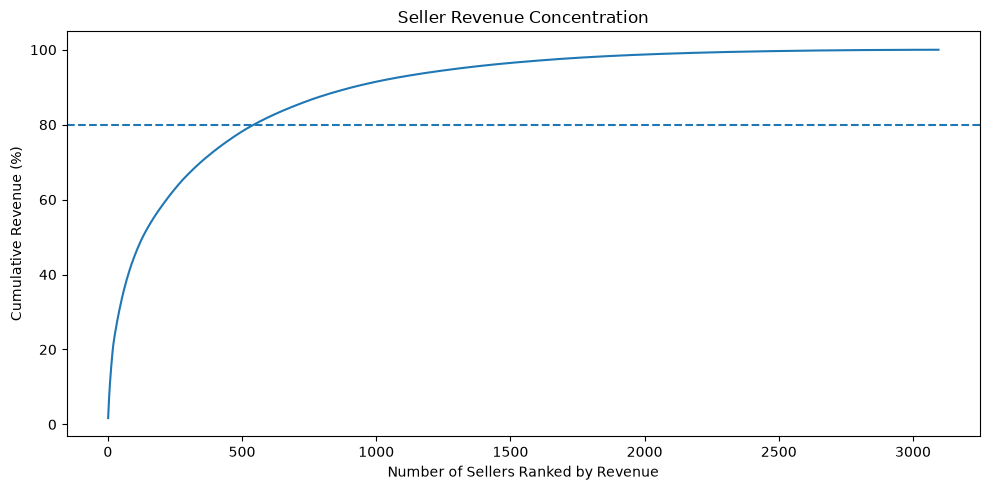

In [190]:
seller_concentration = (
    seller_features[
        [
            "seller_id",
            "seller_revenue"
        ]
    ]
    .sort_values(
        "seller_revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

seller_concentration[
    "rank"
] = (
    seller_concentration.index + 1
)

seller_concentration[
    "cumulative_revenue"
] = (
    seller_concentration[
        "seller_revenue"
    ].cumsum()
)

seller_concentration[
    "cumulative_revenue_pct"
] = (
    seller_concentration[
        "cumulative_revenue"
    ]
    /
    seller_concentration[
        "seller_revenue"
    ].sum()
) * 100

top_10_sellers_share = (
    seller_concentration
    .head(10)[
        "seller_revenue"
    ].sum()
    /
    seller_concentration[
        "seller_revenue"
    ].sum()
) * 100

print(
    "Top 10 sellers revenue share:",
    round(
        top_10_sellers_share,
        2
    ),
    "%"
)

display(
    seller_concentration.head(20)
)

plt.figure(figsize=(10, 5))

plt.plot(
    seller_concentration[
        "rank"
    ],
    seller_concentration[
        "cumulative_revenue_pct"
    ]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.xlabel(
    "Number of Sellers Ranked by Revenue"
)

plt.ylabel(
    "Cumulative Revenue (%)"
)

plt.title(
    "Seller Revenue Concentration"
)

plt.tight_layout()
plt.show()

## 32. Product Concentration Analysis

Top 20 products revenue share: 5.38 %


,product_id,product_revenue,rank,cumulative_revenue,cumulative_revenue_pct
0,bb50f2e236e5eea0100680137654686c,63885.00,1,63885.00,0.470031
1,6cdd53843498f92890544667809f1595,54730.20,2,118615.20,0.872707
2,d6160fb7873f184099d9bc95e30376af,48899.34,3,167514.54,1.232482
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,4,214729.05,1.579861
4,99a4788cb24856965c36a24e339b6058,43025.56,5,257754.61,1.896420
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,6,298837.21,2.198683
6,25c38557cf793876c5abdd5931f922db,38907.32,7,337744.53,2.484942
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,8,375478.43,2.762568
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,9,413161.85,3.039823
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,10,450770.75,3.316529


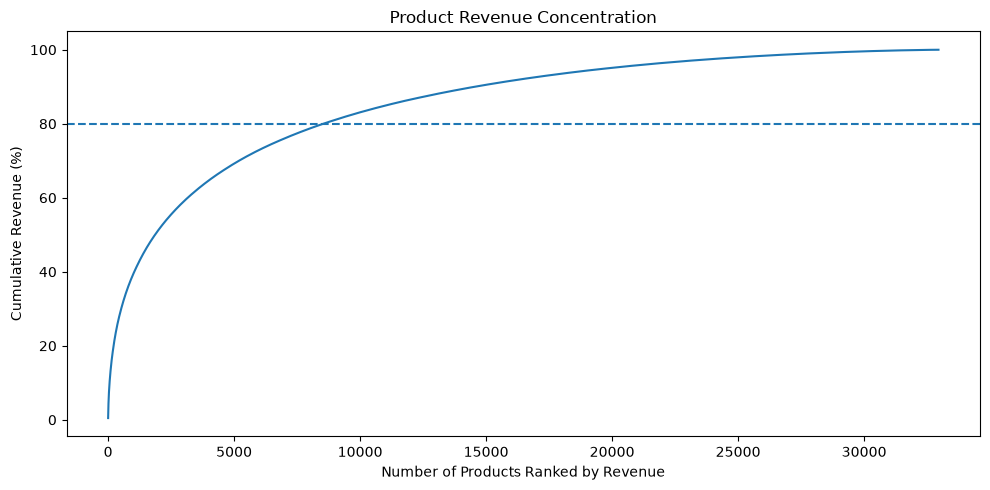

In [191]:
product_concentration = (
    product_features[
        [
            "product_id",
            "product_revenue"
        ]
    ]
    .sort_values(
        "product_revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

product_concentration[
    "rank"
] = (
    product_concentration.index + 1
)

product_concentration[
    "cumulative_revenue"
] = (
    product_concentration[
        "product_revenue"
    ].cumsum()
)

product_concentration[
    "cumulative_revenue_pct"
] = (
    product_concentration[
        "cumulative_revenue"
    ]
    /
    product_concentration[
        "product_revenue"
    ].sum()
) * 100

top_20_products_share = (
    product_concentration
    .head(20)[
        "product_revenue"
    ].sum()
    /
    product_concentration[
        "product_revenue"
    ].sum()
) * 100

print(
    "Top 20 products revenue share:",
    round(
        top_20_products_share,
        2
    ),
    "%"
)

display(
    product_concentration.head(20)
)

plt.figure(figsize=(10, 5))

plt.plot(
    product_concentration[
        "rank"
    ],
    product_concentration[
        "cumulative_revenue_pct"
    ]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.xlabel(
    "Number of Products Ranked by Revenue"
)

plt.ylabel(
    "Cumulative Revenue (%)"
)

plt.title(
    "Product Revenue Concentration"
)

plt.tight_layout()
plt.show()

## 33. Basket Size Analysis

,total_items_per_order,orders,average_order_value
0,0.0,775,0.000000
1,1.0,88863,150.746033
2,2.0,7516,212.307173
3,3.0,1322,292.735696
4,4.0,505,391.661604
5,5.0,204,473.365441
6,6.0,198,531.515152
7,7.0,22,611.453636
8,8.0,8,2304.925000
9,9.0,3,1092.240000


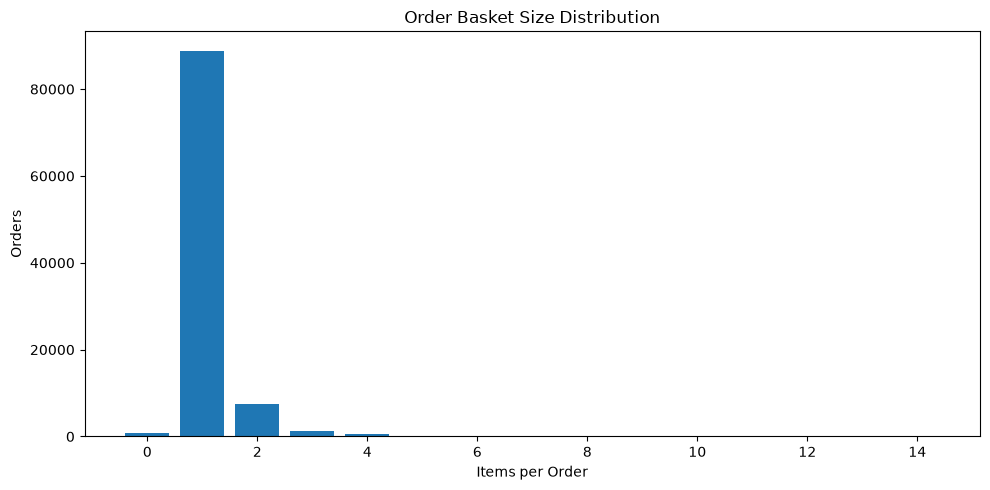

In [192]:
basket_summary = (
    order_features
    .groupby(
        "total_items_per_order",
        as_index=False
    )
    .agg(
        orders=(
            "order_id",
            "nunique"
        ),
        average_order_value=(
            "total_order_value",
            "mean"
        )
    )
    .sort_values(
        "total_items_per_order"
    )
)

display(
    basket_summary.head(20)
)

plt.figure(figsize=(10, 5))

plt.bar(
    basket_summary[
        "total_items_per_order"
    ].head(15),
    basket_summary[
        "orders"
    ].head(15)
)

plt.xlabel("Items per Order")
plt.ylabel("Orders")
plt.title(
    "Order Basket Size Distribution"
)

plt.tight_layout()
plt.show()

## 34. Freight Burden Analysis

,total_order_value,freight_value,freight_percentage
count,98666.000000,98666.000000,98666.000000
mean,160.577638,22.823562,20.880393
std,220.466087,21.650909,12.574904
min,9.590000,0.000000,0.000000
25%,61.980000,13.850000,11.650000
50%,105.290000,17.170000,18.330000
75%,176.870000,24.040000,27.550000
max,13664.080000,1794.960000,95.550000


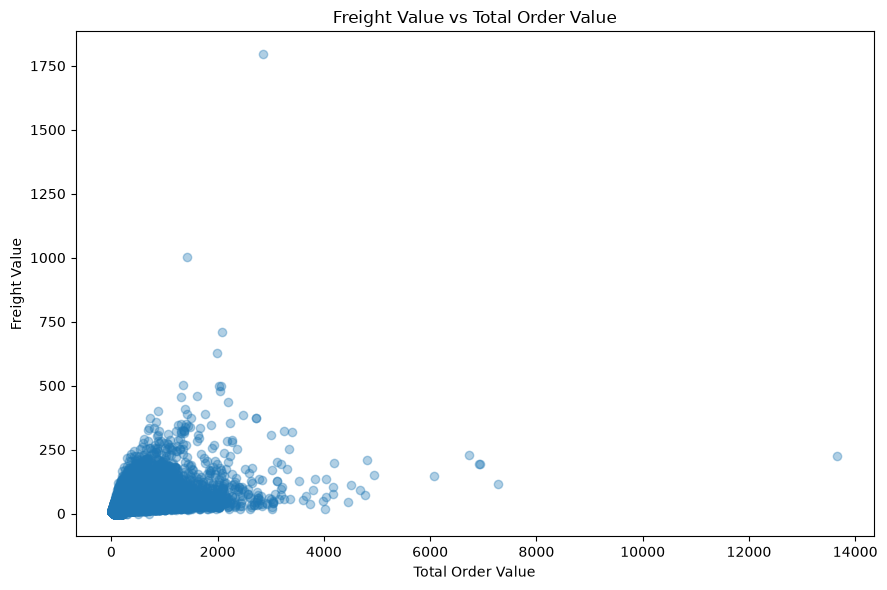

In [193]:
freight_analysis = (
    order_features[
        [
            "total_order_value",
            "freight_value",
            "freight_percentage"
        ]
    ]
    .dropna()
)

display(
    freight_analysis.describe()
)

plt.figure(figsize=(9, 6))

plt.scatter(
    freight_analysis[
        "total_order_value"
    ],
    freight_analysis[
        "freight_value"
    ],
    alpha=0.35
)

plt.xlabel("Total Order Value")
plt.ylabel("Freight Value")
plt.title(
    "Freight Value vs Total Order Value"
)

plt.tight_layout()
plt.show()

## 35. Delivery Performance by Customer State

,customer_state,orders,average_delivery_days,average_delivery_delay,delayed_orders,delayed_rate
1,al,397,24.544005,9.246632,95,23.929471
9,ma,717,21.573138,9.970355,141,19.665272
16,pi,476,19.457101,12.298289,76,15.966387
5,ce,1279,21.266575,14.326786,196,15.324472
24,se,335,21.519701,16.890588,51,15.223881
4,ba,3256,19.335424,11.123487,456,14.004914
18,rj,12350,15.309439,12.856410,1663,13.465587
26,to,274,17.657883,5.652000,35,12.773723
13,pa,946,23.772970,12.303419,117,12.367865
7,es,1995,15.789298,10.596189,244,12.230576


C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\3551756261.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_2092\3551756261.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(


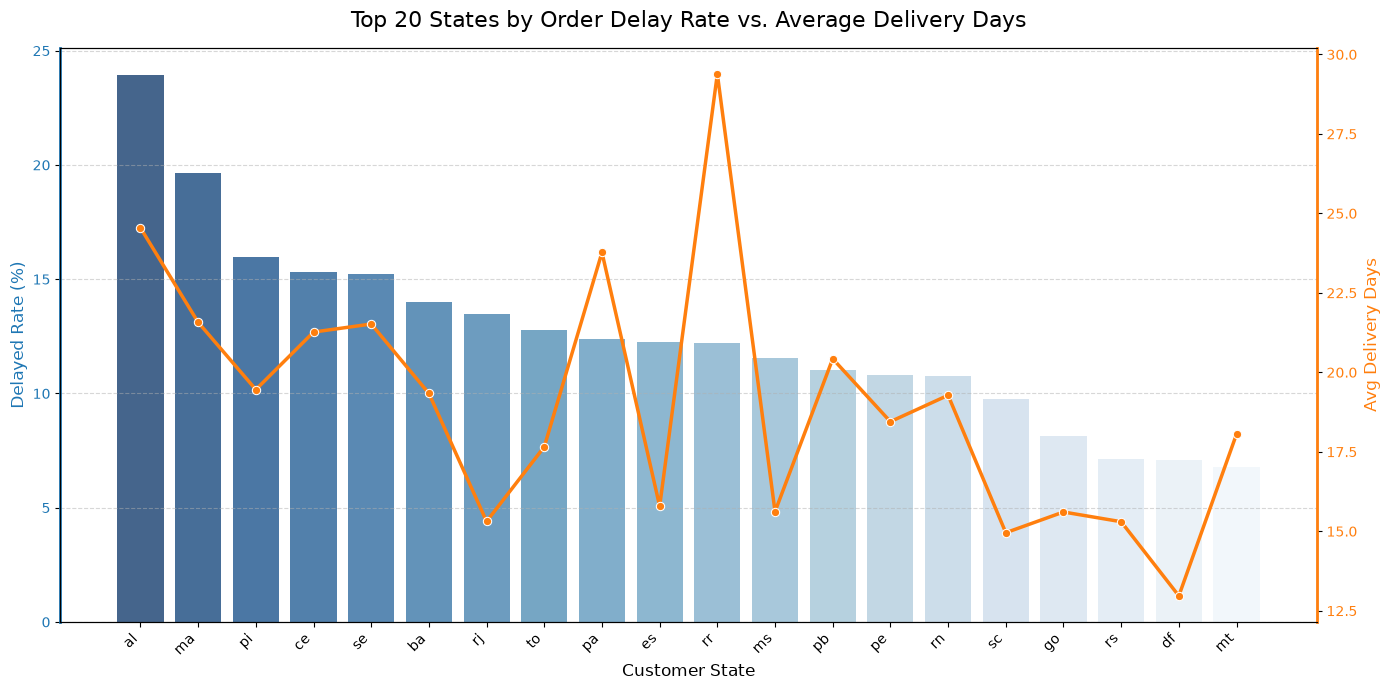

In [194]:
state_delivery = (
    order_features[
        [
            "order_id",
            "customer_state",
            "delivery_status",
            "delivery_days",
            "delivery_delay_days",
        ]
    ]
    .query("delivery_status != 'not_available'")
    .groupby(
        "customer_state",
        as_index=False
    )
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=("delivery_days", "mean"),
        average_delivery_delay=(
            "delivery_delay_days",
            lambda x: x[x > 0].mean()
        ),
        delayed_orders=(
            "delivery_status",
            lambda x: (x == "delayed").sum()
        ),
    )
)

state_delivery["delayed_rate"] = (
    state_delivery["delayed_orders"]
    / state_delivery["orders"]
) * 100

state_delivery = (
    state_delivery
    .sort_values(
        "delayed_rate",
        ascending=False
    )
)

display(state_delivery.head(20))

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=state_delivery.head(20),
    x="customer_state",
    y="delayed_rate",
    ax=ax1,
    palette="Blues_r",
    alpha=0.8,
)

ax1.set_title(
    "Top 20 States by Order Delay Rate vs. Average Delivery Days",
    fontsize=16,
    pad=15,
)

ax1.set_xlabel(
    "Customer State",
    fontsize=12
)

ax1.set_ylabel(
    "Delayed Rate (%)",
    color="tab:blue",
    fontsize=12
)

ax1.tick_params(
    axis="y",
    labelcolor="tab:blue"
)

ax1.spines["left"].set_color("tab:blue")
ax1.spines["left"].set_linewidth(2)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

ax1.set_xticklabels(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right"
)

ax2 = ax1.twinx()

sns.lineplot(
    data=state_delivery.head(20),
    x="customer_state",
    y="average_delivery_days",
    ax=ax2,
    color="tab:orange",
    marker="o",
    linewidth=2.5,
)

ax2.set_ylabel(
    "Avg Delivery Days",
    color="tab:orange",
    fontsize=12
)

ax2.tick_params(
    axis="y",
    labelcolor="tab:orange"
)

ax2.spines["right"].set_color("tab:orange")
ax2.spines["right"].set_linewidth(2)

plt.tight_layout()
plt.show()

## 36. Review Analysis by Product Category

,category_name,average_review_score,reviews
7,bed_bath_table,3.970740,9313
43,health_beauty,4.181203,8771
65,sports_leisure,4.167362,7669
15,computers_accessories,4.026245,6649
39,furniture_decor,4.009691,6398
49,housewares,4.142221,5843
71,watches_gifts,4.065459,5576
68,telephony,4.003119,4168
5,auto,4.090147,3877
69,toys,4.189333,3853


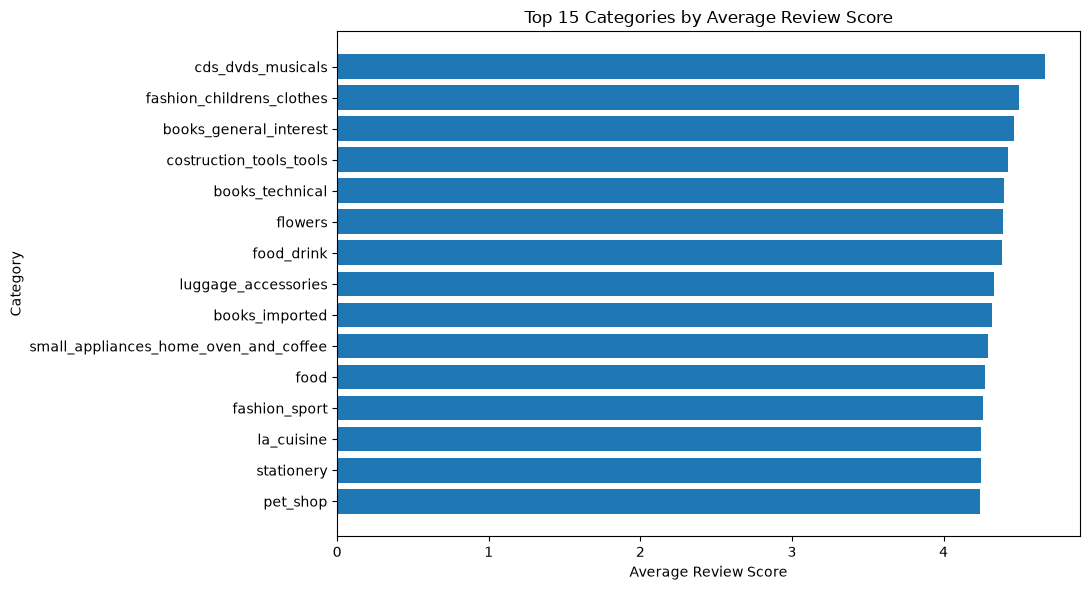

In [195]:
order_category_review = (
    order_category[
        ["order_id", "category_name"]
    ]
    .drop_duplicates()
    .copy()
)

review_map = (
    order_features
    .drop_duplicates("order_id")
    .set_index("order_id")["review_score"]
)

order_category_review["review_score"] = (
    order_category_review["order_id"]
    .map(review_map)
)

review_category_summary = (
    order_category_review
    .dropna(
        subset=[
            "review_score",
            "category_name"
        ]
    )
    .groupby(
        "category_name",
        as_index=False
    )
    .agg(
        average_review_score=("review_score", "mean"),
        reviews=("review_score", "count")
    )
    .sort_values(
        "reviews",
        ascending=False
    )
)

display(review_category_summary.head(20))

review_category_plot = (
    review_category_summary
    .sort_values(
        "average_review_score",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(11, 6))

plt.barh(
    review_category_plot["category_name"].iloc[::-1],
    review_category_plot["average_review_score"].iloc[::-1]
)

plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.title("Top 15 Categories by Average Review Score")

plt.tight_layout()
plt.show()

## 37. Multivariate Summary: Category Revenue, Orders, and Price

,category_name,category_order_count,category_item_count,category_revenue,category_average_price
11,health_beauty,9022,9670,1258681.34,146.776607
66,watches_gifts,5799,5991,1205005.68,335.905481
13,bed_bath_table,10160,11115,1036988.68,107.463381
32,sports_leisure,7858,8641,988048.97,135.441691
44,computers_accessories,6887,7827,911954.32,156.028732
54,furniture_decor,6781,8334,729762.49,103.233978
26,cool_stuff,3658,3796,635290.85,214.696681
73,housewares,6019,6964,632248.66,98.561100
8,auto,3991,4235,592720.11,152.576804
40,garden_tools,3607,4347,485256.46,222.614460


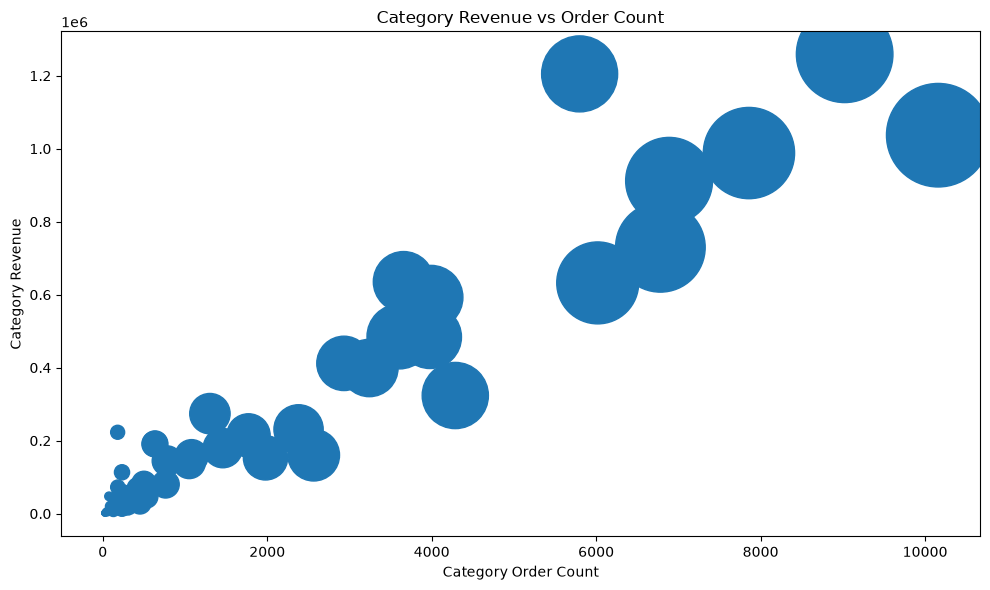

In [196]:
category_multivariate = (
    category_features[
        [
            "category_name",
            "category_order_count",
            "category_item_count",
            "category_revenue",
            "category_average_price"
        ]
    ]
    .sort_values(
        "category_revenue",
        ascending=False
    )
)

display(
    category_multivariate.head(20)
)

plt.figure(figsize=(10, 6))
plt.scatter(
    category_multivariate["category_order_count"],
    category_multivariate["category_revenue"],
    s=(
        category_multivariate["category_item_count"]
        .clip(lower=1)
    ) / 2
)
plt.xlabel("Category Order Count")
plt.ylabel("Category Revenue")
plt.title("Category Revenue vs Order Count")
plt.tight_layout()
plt.show()

## 38. EDA Data Quality Check

In [197]:
eda_missing = pd.DataFrame({
    "Dataset": [
        "order_features",
        "customer_features",
        "seller_features",
        "product_features",
        "category_features",
        "order_reviews",
        "order_payments"
    ],
    "Missing Values": [
        int(order_features.isna().sum().sum()),
        int(customer_features.isna().sum().sum()),
        int(seller_features.isna().sum().sum()),
        int(product_features.isna().sum().sum()),
        int(category_features.isna().sum().sum()),
        int(order_reviews.isna().sum().sum()),
        int(order_payments.isna().sum().sum())
    ]
})

eda_missing

,Dataset,Missing Values
0,order_features,20851
1,customer_features,2746
2,seller_features,0
3,product_features,0
4,category_features,0
5,order_reviews,0
6,order_payments,0


## 39. EDA Tables 

In [198]:
ttest_ready = (
    order_features[
        [
            "order_id",
            "delivery_status",
            "review_score"
        ]
    ]
    .query(
        "delivery_status in ['on_time', 'delayed']"
    )
    .dropna(
        subset=["review_score"]
    )
)

ttest_summary = (
    ttest_ready
    .groupby(
        "delivery_status"
    )
    .agg(
        orders=(
            "order_id",
            "nunique"
        ),
        average_review_score=(
            "review_score",
            "mean"
        ),
        median_review_score=(
            "review_score",
            "median"
        ),
        std_review_score=(
            "review_score",
            "std"
        )
    )
    .reset_index()
)

anova_category_counts = (
    order_category
    .groupby("order_id")[
        "category_name"
    ]
    .nunique()
)

single_category_order_ids = (
    anova_category_counts[
        anova_category_counts == 1
    ]
    .index
)

anova_ready = (
    order_category[
        order_category[
            "order_id"
        ].isin(
            single_category_order_ids
        )
    ]
    .groupby(
        [
            "order_id",
            "category_name"
        ],
        as_index=False
    )
    .agg(
        order_value=(
            "price",
            "sum"
        ),
        freight_value=(
            "freight_value",
            "sum"
        )
    )
)

anova_ready[
    "order_value"
] = (
    anova_ready["order_value"]
    +
    anova_ready["freight_value"]
)

chi_square_ready = payment_order[
    [
        "order_id",
        "payment_type",
        "order_status"
    ]
].dropna()

chi_square_table = pd.crosstab(
    chi_square_ready[
        "payment_type"
    ],
    chi_square_ready[
        "order_status"
    ]
)

print(
    "T-test preparation rows:",
    len(ttest_ready)
)

print(
    "ANOVA preparation rows:",
    len(anova_ready)
)

print(
    "Chi-square preparation rows:",
    len(chi_square_ready)
)

display(ttest_summary)

display(chi_square_table)

T-test preparation rows: 95824
ANOVA preparation rows: 97880
Chi-square preparation rows: 99440


,delivery_status,orders,average_review_score,median_review_score,std_review_score
0,delayed,7655,2.565121,2.0,1.657595
1,on_time,88169,4.294295,5.0,1.146007


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0,95,2,19191,67,70,209,150
credit_card,2,432,3,72785,231,219,836,427
debit_card,0,7,0,1484,6,2,22,6
unknown,0,3,0,0,0,0,0,0
voucher,0,88,0,3017,10,10,40,26


## 40. Key EDA Output Tables

In [199]:
top_category_table = (
    category_features[
        [
            "category_name",
            "category_revenue",
            "category_order_count",
            "category_item_count",
            "category_average_price"
        ]
    ]
    .sort_values(
        "category_revenue",
        ascending=False
    )
    .head(10)
)

top_product_table = (
    product_features[
        [
            "product_id",
            "category_name",
            "product_revenue",
            "product_order_count",
            "product_item_count",
            "product_average_price"
        ]
    ]
    .sort_values(
        "product_revenue",
        ascending=False
    )
    .head(10)
)

top_seller_table = (
    seller_features[
        [
            "seller_id",
            "seller_revenue",
            "seller_order_count",
            "seller_item_count",
            "seller_unique_products"
        ]
    ]
    .sort_values(
        "seller_revenue",
        ascending=False
    )
    .head(10)
)

print("Top 10 Categories")
display(top_category_table)

print("Top 10 Products")
display(top_product_table)

print("Top 10 Sellers")
display(top_seller_table)

Top 10 Categories


,category_name,category_revenue,category_order_count,category_item_count,category_average_price
11,health_beauty,1258681.34,9022,9670,146.776607
66,watches_gifts,1205005.68,5799,5991,335.905481
13,bed_bath_table,1036988.68,10160,11115,107.463381
32,sports_leisure,988048.97,7858,8641,135.441691
44,computers_accessories,911954.32,6887,7827,156.028732
54,furniture_decor,729762.49,6781,8334,103.233978
26,cool_stuff,635290.85,3658,3796,214.696681
73,housewares,632248.66,6019,6964,98.561100
8,auto,592720.11,3991,4235,152.576804
40,garden_tools,485256.46,3607,4347,222.614460


Top 10 Products


,product_id,category_name,product_revenue,product_order_count,product_item_count,product_average_price
24086,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00,187,195,327.615385
14068,6cdd53843498f92890544667809f1595,health_beauty,54730.20,151,156,350.834615
27613,d6160fb7873f184099d9bc95e30376af,computers,48899.34,35,35,1397.124000
27039,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51,323,343,137.651633
19742,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56,467,488,88.167131
8051,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,41082.60,255,274,149.936496
4996,25c38557cf793876c5abdd5931f922db,baby,38907.32,38,38,1023.876842
12351,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,63,63,598.950794
10867,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37683.42,306,323,116.666935
22112,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37608.90,431,527,71.364137


Top 10 Sellers


,seller_id,seller_revenue,seller_order_count,seller_item_count,seller_unique_products
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,95
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,23
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,399
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,289
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,198
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,186
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,222
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,149
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,154
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,104
